# Intro and Set Up #

In [1]:
import csv
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch 
import torch.nn as nn
from tqdm import tqdm
from scipy.stats import norm
import os

import matplotlib.pyplot as plt
import seaborn as sns

from tools.Parametric_Structure_Eval import StructureEval as SE

#Import min-max scaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

RANDOM_SEED = 41
VALIDATION_ARTIFACT_DIR = Path('./Figures')
VALIDATION_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# Seed every source of randomness used by the surrogate-training cells.
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## Format the Parametric Training Data ##


In [2]:
def merge_data(file_path, file_root_list, save_name): 
    #This function merges multiple CSV files into a single DataFrame.
    random_error_idx = []
    for file_root_name in file_root_list:
        df = pd.read_csv(f"{file_path}/Random_Parametric_Designs_{file_root_name}_Updated.csv")

        if 'df_merged' in locals():
            # Rename columns of df to match those of df_merged
            df.columns = header
            df_merged = pd.concat([df_merged, df], ignore_index=True)

        else:
            df_merged = df
            header = df.columns.tolist()
        
        # Load error indices if they exist
        try:
            error_idx = np.loadtxt(f"{file_path}/random_test_design_error_idx_{file_root_name}.csv", delimiter=',').astype(np.int64)
            
            try:
                len(error_idx)
            except:
                error_idx = np.array([error_idx])
            random_error_idx.extend(error_idx.tolist())
        except:
            print(f"No error indices found for {file_root_name}.")
    
    df_merged.to_csv(f"{file_path}/{save_name}_Parameters_All.csv", index=False)
    #Save the error indices to a CSV file
    if random_error_idx:
        print(random_error_idx)

        np.savetxt(f"{file_path}/random_test_design_error_idx_All.csv", random_error_idx, delimiter=',', fmt='%d')
    


# Read in the structural elements data
df_columns = np.array(['Steel_Volume [m^3]',
               'Steel_Weight [tons]',
               'Unit_Steel_Weight [tons/m^3]',
               'Steel_LCG [m]',
               'Steel_YCG [m]',
               'Steel_VCG [m]',
               'Cross_Sectional_Area [m^2]',
               'z_Centroid_CX [m]',
               'y_Centroid_CX [m]',
               'I_11 [m^4]',
               'I_22 [m^4]', 
               'Max_Bending_Moment [Nm]'
               ])
    

def format_training_data(file_path, file_root_name, num_samples):
    """
    Reads in the Structural_elements.csv file, evaluates the structural elements, and formats the data for training.
    
    Parameters:
    - file_path: Path to the directory containing the CSV files.
    - file_root_name: Root name of the CSV files to be processed.
    - num_samples: Number of samples to process.
    
    Returns:
    - df_formatted: DataFrame containing formatted training data.
    """
    data = np.zeros((num_samples, 12))
    constraint_thresholds = pd.DataFrame(index=np.arange(num_samples))
    constraint_evals = pd.DataFrame(index=np.arange(num_samples))
    error_idx = []
    try:
        error_idx = np.loadtxt(f"{file_path}/{file_root_name}_error_idx_ALL.csv", delimiter=',').astype(np.int64)
        #error_idx = pd.read_csv(f"{file_path}/random_test_design_error_idx_All.csv", header=None).iloc[:,0].tolist()
        len(error_idx)
        print(f"Error indices found: {error_idx}")
    except:
        print(f"No error indices found for {file_root_name}.")
        error_idx = []
    
    check_labels = True
    for i in tqdm(range(num_samples)):
        #Check if the index is in the error list
        
        if i in error_idx:
            print(f"Skipping index {i} due to previous error.")
            data[i, :] = np.nan
            continue
        try:
            df = pd.read_csv(f"{file_path}/{file_root_name}_{i}_Structural_elements.csv")
        except:
            print(f"Error reading file for index {i}. Skipping this sample.")
            data[i, :] = np.nan
            continue
        
        structE = SE(df)
        data[i, 0] = structE.Volume()
        data[i, 1:3] = structE.Structural_Weight()
        data[i, 3:6] = structE.Volume_Centroid()
        data[i, 6:12] = structE.Effective_Longitudinal_CrossSection_Properties()

        thresh, evals = structE.Calculate_Transverse_Struct_Constraints()
        if check_labels: 
            constraint_thresholds = pd.DataFrame(columns=thresh.keys(), index=np.arange(num_samples))
            constraint_evals = pd.DataFrame(columns=evals.keys(), index=np.arange(num_samples))
            spacings,dims = structE.Calculate_Spacings_and_Sizes()

            print(spacings)
            print(dims)
            check_labels = False
            
        constraint_thresholds.iloc[i] = thresh
        constraint_evals.iloc[i] = evals

        
    
    # Create a DataFrame with the formatted data
    #print(data)
    df_formatted = pd.DataFrame(data, columns=df_columns)
    

    # Save the formatted data to a CSV file
    df_formatted.to_csv(f"{file_path}/{file_root_name}_Structural_Properties.csv", index=False)
    # convert all nans to 0s in the constraint dataframes and save them
    constraint_thresholds = constraint_thresholds.fillna(0.0)
    constraint_evals = constraint_evals.fillna(0.0)


    # All spacing reqs are 'Maximum' so we multiply these by -1 to convert them to 'Minimum' for the constraint evaluation

    spacing_cons_names = np.array(['Bottom_Floor_Spacing'
                                   ])
    for cons in spacing_cons_names:
        constraint_thresholds[cons] = -1.0*constraint_thresholds[cons]
        constraint_evals[cons] = -1.0*constraint_evals[cons]


    constraint_thresholds.to_csv(f"{file_path}/{file_root_name}_Constraint_Thresholds.csv", index=False)
    constraint_evals.to_csv(f"{file_path}/{file_root_name}_Constraint_Values.csv", index=False)
    




In [3]:
file_path = '/Users/noahbagazinski/Documents/MIT/Research/Ship_Structures/Dataset_Structures_V2_1'
#file_root_name = 'parametric_test_design'
file_root_name = 'random_test_design'
num_samples = 6050

merge_data(file_path, np.array(['0_999', '1000_1999', '2000_3999', '4000_4999', '5000_6049']), file_root_name) #999', '4000_4999', '5000_5006']))

#format_training_data(file_path, file_root_name, num_samples)


    
   

[562, 683, 1185, 1335, 1979, 2239, 2292, 2435, 2699, 2975, 3106, 3349, 3380, 3402, 3526, 3545, 3937, 4075, 4077, 4129, 4203, 4505, 4705, 4780, 4922, 4974, 5375, 5488, 5627, 5685]


### Hopper Stiffener Check ###

In [4]:
## Side Function: Evaluate the structural elements/parameters and check if the hopper stiffeners interfere with the tranvsverse bulkhead stiffeners. This is a side function that is not used in the main training and optimization process, but can be used to check if the hopper stiffeners interfere with the transverse bulkhead stiffeners.


def check_hopper_bulkhead_interference(file_path, file_root_name, num_samples):
    """
    Reads in the Structural_elements.csv file, evaluates the structural elements, and formats the data for training.
    
    Parameters:
    - file_path: Path to the directory containing the CSV files.
    - file_root_name: Root name of the CSV files to be processed.
    - num_samples: Number of samples to process.
    
    Returns:
    Hopper_data. a dataframe that contains an evaluation on the hopper stiffeners and their interference with the transverse bulkhead stiffeners.
    """

    #Assign hopper_data to have length of num_samples and columns for the index, structure class, and the minimum distances between the hopper stiffeners and the transverse bulkhead stiffeners.
    hopper_data = pd.DataFrame(columns=['Index', 
                                        'Structure_Class', 
                                        'Min Y dist: Hop stiff. vs Vert. Blkhd Stiff', 
                                        'Min Z dist: Hop stiff. vs Horiz. Blkhd Stiff', 
                                        'Min Y dist: Lower Hop stiff. vs Long. Blkhd',  
                                        'bit_Hopper_Stiff_too_Close_50mm', 
                                        'bit_Hopper_Stiff_too_Close_100mm'])
    
    hopper_data = hopper_data.reindex(index=np.arange(num_samples))

  
    error_idx = np.loadtxt(f"{file_path}/{file_root_name}_error_idx_ALL.csv", delimiter=',', dtype=int)
    try:
        len(error_idx)
        print(f"Error indices found: {error_idx}")
    except:
        error_idx = [error_idx]
    
    check_labels = True

    for i in tqdm(range(num_samples)):
        #Check if the index is in the error list
        
        if i in error_idx:
            print(f"Skipping index {i} due to previous error.")
            continue

        df = pd.read_csv(f"{file_path}/{file_root_name}_{i}_Structural_elements.csv")
        structE = SE(df)

        # First check for existence of 'Hopper Pannel' in 'Class'
        if 'Hopper Pannel' in df['Class'].values:
            # Get Object ID of Hopper_Pannels
            hopper_ids = df[df['Class'] == 'Hopper Pannel']['Object_ID'].unique()
            # Get rot of first hopper pannel
            hopper_rot = df[df['Class'] == 'Hopper Pannel']['rot'].values[0]


            #Get Unique Y and Z positions of the hopper stiffeners - objects with Parent_Struct in hopper_ids. 
            Ys = df[df['Parent_Struct'].isin(hopper_ids)]['y_loc'].unique()
            Zs = df[df['Parent_Struct'].isin(hopper_ids)]['z_loc'].unique()

            #print(f"Index: {i}, Hopper Stiffener Y positions: {Ys}, Z positions: {Zs}")

            # Get vert bulkhead stiffeners - objects with Class 'Transverse_Bulkhead_Vertical_Stiffener'
            Y_blkhd_stiffs = df[df['Class'] == 'Transverse_Bulkhead_Vertical_Stiffener']['y_loc'].unique()
            # Get horiz bulkhead stiffeners - objects with Class 'Transverse_Bulkhead_Horizontal_Stiffener'
            Z_blkhd_stiffs = df[df['Class'] == 'Transverse_Bulkhead_Transverse_Stiffener']['z_loc'].unique()

            #print(f"Index: {i}, Vertical Bulkhead Stiffener Y positions: {Y_blkhd_stiffs}, Horizontal Bulkhead Stiffener Z positions: {Z_blkhd_stiffs}")

            # Calculate the abs difference between all the Ys and Y_blkhd_stiffs, and find the minimum distance that is not zero
            diffs = np.abs(Ys[:, None] - Y_blkhd_stiffs[None, :])
            diffs[diffs< 1e-10] = 1.0  # Ignore zero differences
            min_Y_dist = np.min(diffs)
            # Calculate the abs difference between all the Zs and Z_blkhd_stiffs, and find the minimum distance
            diffs_z = np.abs(Zs[:, None] - Z_blkhd_stiffs[None, :])
            diffs_z[diffs_z< 1e-10] = 1.0  # Ignore zero differences
            min_Z_dist = np.min(diffs_z)

            #Assign values to the hopper_data dataframe
            hopper_data.loc[i, 'Index'] = i
            if hopper_rot == 90:
                hopper_data.loc[i, 'Structure_Class'] = 'containership'
            else:
                hopper_data.loc[i, 'Structure_Class'] = 'bulkcarrier'
            
            hopper_data.loc[i, 'Min Y dist: Hop stiff. vs Vert. Blkhd Stiff'] = min_Y_dist
            hopper_data.loc[i, 'Min Z dist: Hop stiff. vs Horiz. Blkhd Stiff'] = min_Z_dist

            # Now check for longitudinal bulkhead and inner side shell interference with the lower hopper stiffeners.
            if 'Longitudinal_Bulkhead' in df['Class'].values:
                # Get Object ID of Longitudinal_Bulkhead
                long_blkhd_ids = df[df['Class'] == 'Longitudinal_Bulkhead']['Object_ID'].unique()
                # Get Y positions of the longitudinal bulkhead stiffeners - objects with Parent_Struct in long_blkhd_ids. 
                y_long_blkhd = df[df['Parent_Struct'].isin(long_blkhd_ids)]['y_loc'].unique()
                # Calculate the abs difference between all the Ys and y_long_blkhd, and find the minimum distance
                diffs_long_blkhd = np.abs(Ys[:, None] - y_long_blkhd[None, :])
                diffs_long_blkhd[diffs_long_blkhd < 1e-10] = 1.0
                min_Y_dist_long_blkhd = np.min(diffs_long_blkhd)
                hopper_data.loc[i, 'Min Y dist: Lower Hop stiff. vs Long. Blkhd'] = min_Y_dist_long_blkhd
            else:
                min_Y_dist_long_blkhd = 1.0


            # Check if any of the three distances are less than 0.05m  account for nan in min_y_dist_long_blkhd

            if (min_Y_dist < 0.05) or (min_Z_dist < 0.05) or (min_Y_dist_long_blkhd < 0.05):
                hopper_data.loc[i, 'bit_Hopper_Stiff_too_Close_50mm'] = 1
            else:
                hopper_data.loc[i, 'bit_Hopper_Stiff_too_Close_50mm'] = 0

            if (min_Y_dist < 0.1) or (min_Z_dist < 0.1) or (min_Y_dist_long_blkhd < 0.1):
                hopper_data.loc[i, 'bit_Hopper_Stiff_too_Close_100mm'] = 1
            else:
                hopper_data.loc[i, 'bit_Hopper_Stiff_too_Close_100mm'] = 0
        else:
            hopper_data.loc[i, 'Index'] = i
            hopper_data.loc[i, 'Structure_Class'] = 'tanker'


    # Save the hopper_data to a CSV file
    hopper_data.to_csv(f"{file_path}/{file_root_name}_Hopper_Stiffener_Interference.csv", index=False)
    num_violations = hopper_data['bit_Hopper_Stiff_too_Close_50mm'].sum()
    print(f"Number of designs with 50mm hopper stiffener interference: {num_violations}")

    num_violations = hopper_data['bit_Hopper_Stiff_too_Close_100mm'].sum()
    print(f"Number of designs with 100mm hopper stiffener interference: {num_violations}")

    nonTanker_hopper_data = hopper_data[hopper_data['Structure_Class'] != 'tanker'].values
    print(f"Number of non-tanker designs: {len(nonTanker_hopper_data)}")

    return hopper_data

file_path = '/Users/noahbagazinski/Documents/MIT/Research/Ship_Structures/Dataset_Structures_V2_1'
#file_root_name = 'parametric_test_design'
file_root_name = 'random_test_design'
num_samples = 1000
#num_samples = 3

#hopper_df = check_hopper_bulkhead_interference(file_path, file_root_name, num_samples)
           
            



        





## Set Up Machine Learning Models ##

In [3]:
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(MLP, self).__init__()
        self.fc = nn.ModuleList() 
        self.fc.append(self.layer(input_size, hidden_size[0]))
        for i in range(1, len(hidden_size)):
            self.fc.append(self.layer(hidden_size[i-1], hidden_size[i]))
        self.fc.append(nn.Linear(hidden_size[-1], output_size))
        
    def layer(self, dim_in, dim_out, dropout=0.25):
        l = nn.Sequential(
            nn.Linear(dim_in, dim_out),
            nn.ReLU(),
            nn.Dropout(dropout))
        return l

    def forward(self, x):
        for L in self.fc:
            x = L(x)
        return x
    

class Classifer(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(Classifer, self).__init__()
        self.fc = nn.ModuleList() 
        self.fc.append(self.layer(input_size, hidden_size[0]))
        for i in range(1, len(hidden_size)):
            self.fc.append(self.layer(hidden_size[i-1], hidden_size[i]))
        self.fc.append(nn.Linear(hidden_size[-1], output_size))
        
    def layer(self, dim_in, dim_out, dropout=0.25):
        l = nn.Sequential(
            nn.Linear(dim_in, dim_out),
            nn.ReLU(),
            nn.Dropout(dropout))
        return l

    def forward(self, x):
        for L in self.fc[:-1]:
            x = L(x)
        x = self.fc[-1](x)
        return torch.sigmoid(x)



## Load the Data in and Visualize

In [6]:
#Load X Data info: 
path = '/Users/noahbagazinski/Documents/MIT/Research/Ship_Structures/Dataset_Structures_V2_1'

error_idx = np.loadtxt(f"{path}/random_test_design_error_idx_All.csv", delimiter=',', dtype=int)

#Load X Data:
X_data = pd.read_csv(path + '/random_test_design_Parameters_All.csv')


#Load y Data:
Y_data = pd.read_csv(path + '/random_test_design_Structural_Properties.csv')


#Remove error indices from X_data and Y_data
X_data = X_data.drop(index=error_idx)
Y_data = Y_data.drop(index=error_idx)

#check if the number of samples match
if X_data.shape[0] != Y_data.shape[0]:
    raise ValueError("Number of samples in X_data and Y_data do not match after removing error indices.")


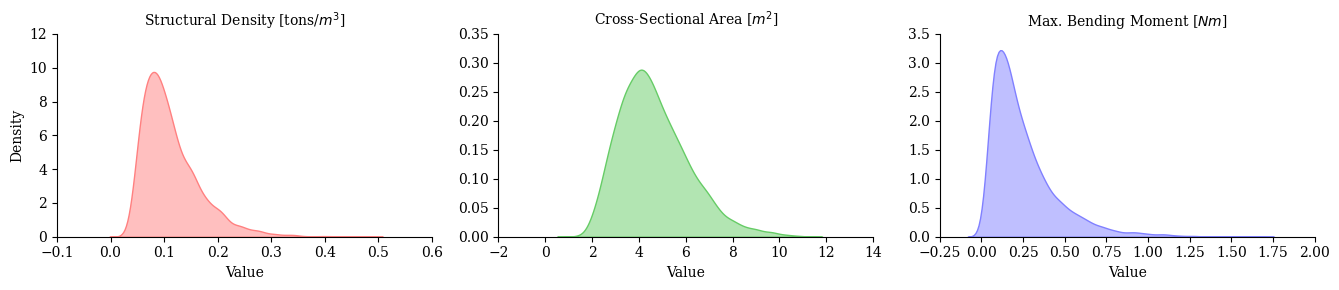

In [ ]:
#Let's plot a kde of each of the Y_data columns

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = '10' 

colors = [[1,.5,.5], 
          [.4,.8,.4], 
          [.5,.5,1],
          [1,.5,.5],
          [.4,.8,.4],
          [.5,.5,1]]

idx = [2, 6, 11]  # Indices of the columns to plot
columns_to_plot = df_columns[idx]

Y_data_subset = Y_data.melt(id_vars=None, value_vars=columns_to_plot, var_name='Structural Property', value_name='Val')

#Rename the columns in Y_data_subset for clarity
Y_data_subset['Structural Property'] = Y_data_subset['Structural Property'].replace({
    'Unit_Steel_Weight [tons/m^3]': r'Structural Density [tons/$m^3$]',
    r'Cross_Sectional_Area [m^2]': r'Cross-Sectional Area [$m^2$]',
     'Max_Bending_Moment [Nm]': r'Max. Bending Moment [$Nm$]'
})

#create new df with log values
Y_log = Y_data_subset.copy()
Y_log['Val'] = np.log(Y_log['Val'])

#rename items in 'Structural Property' column for clarity
Y_log['Structural Property'] = Y_log['Structural Property'].replace({
    r'Structural Density [tons/$m^3$]' : 'Log(Structural Density)',
    r'Cross-Sectional Area [$m^2$]' : 'Log(Cross-Sectional Area)',
    r'Max. Bending Moment [$Nm$]' : r'Log(Max. Bending Moment)'
  
})

#concatenate the original and log dataframes
#Y_data_subset = pd.concat([Y_data_subset, Y_log], ignore_index=True)


#now make a kde plot in. facetgrid. one row is 'Value' and the other row is 'Log Value'
g = sns.FacetGrid(Y_data_subset, col='Structural Property', sharex=False, sharey=False, height=3, aspect=1.5, col_wrap=3)

for ax, color, var in zip(g.axes.flatten(), colors, Y_data_subset["Structural Property"].unique()):
    sns.kdeplot(
        data=Y_data_subset[Y_data_subset["Structural Property"] == var],
        x="Val",
        fill=True,
        ax=ax,
        color=color,
        alpha=0.5
    )
    ax.ticklabel_format(style='sci', axis='y')
    #mu, std = Y_data_subset[Y_data_subset["Structural Property"] == var]["Val"].mean(), Y_data_subset[Y_data_subset["Structural Property"] == var]["Val"].std()
    #x = np.linspace(mu - 3*std, mu + 3*std, 100)
    #ax.plot(x, norm.pdf(x,mu,std), color=(0.3,0.3,0.3),linewidth = 0.85, linestyle='--', label=r'Normal Dist. Around $\mu, \sig$ of Data')

#Change x-axis labels 

#g.set_axis_labels("Value", "Density", fontsize=10)


#format scinetific notati

g.set_xticklabels(fontsize=10)
g.set_yticklabels(fontsize=10)
g.set_titles("{col_name}")
#plt.legend()
plt.tight_layout()


plt.savefig('./Figures/Performance_Metrics_Range.png', dpi=450)
plt.show()





    

# Machine Learning #

## Set up ML Training 

In [4]:
#Load X Data info: 
path = '/Users/noahbagazinski/Documents/MIT/Research/Ship_Structures/Dataset_Structures_V2_1'
error_idx = np.loadtxt(f"{path}/random_test_design_error_idx_All.csv", delimiter=',', dtype=int)

#Load X Data:
X_data = pd.read_csv(path + '/random_test_design_Parameters_All.csv')

#Load y Data:
Y_data = pd.read_csv(path + '/random_test_design_Structural_Properties.csv')

#Remove error indices from X_data and Y_data
X_data = X_data.drop(index=error_idx)
Y_data = Y_data.drop(index=error_idx)

# Check that the retained parameter and performance rows remain synchronized.
if X_data.shape[0] != Y_data.shape[0]:
    raise ValueError("Number of samples in X_data and Y_data do not match after removing error indices.")

if X_data.shape[0] != 6020:
    raise ValueError(f"Expected 6020 retained random designs, found {X_data.shape[0]}.")

# Create one shared, deterministic, ship-class-stratified split for both surrogate models.
retained_dataset_indices = X_data.index.to_numpy(copy=True)
ship_class_columns = ['cat tanker', 'cat container', 'cat bulkcarrier']
ship_class_indicator = X_data[ship_class_columns]
if not np.allclose(ship_class_indicator.sum(axis=1).to_numpy(), 1.0):
    raise ValueError("Every retained design must have exactly one ship-class indicator.")
ship_class = ship_class_indicator.idxmax(axis=1).str.replace('cat ', '', regex=False).to_numpy()
retained_positions = np.arange(X_data.shape[0])
train_indices, validation_indices = train_test_split(
    retained_positions,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=ship_class
)

# Save row-level split provenance so every reported validation value is reproducible.
split_assignment = np.full(X_data.shape[0], 'training', dtype=object)
split_assignment[validation_indices] = 'validation'
validation_split = pd.DataFrame({
    'retained_position': retained_positions,
    'dataset_row_index': retained_dataset_indices,
    'ship_class': ship_class,
    'split': split_assignment
})
validation_split.to_csv(VALIDATION_ARTIFACT_DIR / 'Surrogate_Validation_Split.csv', index=False)

Y_s = np.log(Y_data[df_columns[[2,6,11]]].values)
X_s = X_data.values

def feature_engineer_X(X):
    #Feature Engineering: Lets get some known ratios examined and square all terms to get better performance from the MLP.
    X_ratios = np.array( [X[:,0]/X[:,15], # Ratio of length to N webframes
                          X[:,0]/X[:,92], #Ratio of length to N frames
                          X[:,1]/X[:,16],  # Ratio of Beam to N bottom girders
                          X[:,1]/X[:,17], #Ratio of Beam to N bottom stiffeners
                          X[:,1]/X[:,18], #Ratio of Beam to N deck girders
                          X[:,1]/X[:,19], #Ratio of Beam to N deck stiffeners
                          X[:,1]/X[:,21], #Ratio of Beam to N vertical bulkhead stiffeners
                          X[:,3]/X[:,20], #Ratio of depth to N side shell stiffeners
                          X[:,3]/X[:,22] ]).transpose() # Ratio of depth to N horizontal bulkhead stiffeners])



    #concatenate the original with squared values of x
    X = np.concatenate((X, 
                          X_ratios
                          ), axis=1)

    X = np.concatenate((X, X**2), axis=1)
    
    return X





In [5]:
# Fit every preprocessing transformation on the training partition only.
Y_scaler_obj = StandardScaler()
Y_scaler_obj.fit(Y_s[train_indices])
Y_train = Y_scaler_obj.transform(Y_s[train_indices])
Y_validation = Y_scaler_obj.transform(Y_s[validation_indices])

y_labels = np.array([
    'Structural density [metric tons/m^3]',
    'Cross-sectional area [m^2]',
    'Maximum bending moment [N m]'
])

X_param_scaler = StandardScaler()
X_param_scaler.fit(X_s[train_indices])
X_p_train = X_param_scaler.transform(X_s[train_indices])
X_p_validation = X_param_scaler.transform(X_s[validation_indices])

print(f"Performance surrogate rows: {len(train_indices)} training, {len(validation_indices)} validation")


Performance surrogate rows: 4816 training, 1204 validation


In [6]:
# Create a deterministically shuffled data loader.
def create_data_loader(X, labels, batch_size, random_seed=RANDOM_SEED):
    dataset = torch.utils.data.TensorDataset(torch.tensor(X).float(), torch.tensor(labels).float())
    generator = torch.Generator()
    generator.manual_seed(random_seed)
    data_loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=generator
    )
    return data_loader


batch_size = 64


In [7]:
# Train the performance surrogate on the shared training partition.
data_loader_1 = create_data_loader(X_p_train, Y_train, batch_size, random_seed=RANDOM_SEED)

# Reset the model-initialization seed immediately before constructing the network.
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
model_1 = MLP(X_p_train.shape[1], [128,128], Y_train.shape[1])
model_1.to(device)
model_1.train()

optimizer = torch.optim.Adam(model_1.parameters(), lr=0.001)
criteria = nn.MSELoss()

num_epochs = 1000
import time

start = time.time()

for epoch in tqdm(range(num_epochs)):
    for X_batch, Y_batch in data_loader_1:
        X_batch = X_batch.to(device)
        Y_batch = Y_batch.to(device)
        optimizer.zero_grad()
        output = model_1(X_batch)
        loss = criteria(output, Y_batch)
        loss.backward()
        optimizer.step()
    if(epoch % 500 == 0):
        print(f'Epoch {epoch+1}/{num_epochs}, Loss: {loss.item()}')

mid = time.time()
# Evaluate every row in the untouched validation partition.
X_p_validation_tensor = torch.tensor(X_p_validation).float().to(device)
model_1.eval()
with torch.no_grad():
    output_validation = model_1(X_p_validation_tensor).cpu().numpy()

output_validation_physical = np.exp(Y_scaler_obj.inverse_transform(output_validation))
Y_validation_physical = np.exp(Y_scaler_obj.inverse_transform(Y_validation))
end = time.time()

print(f"Training time: {mid - start} seconds")
print(f"Testing time: {end - mid} seconds")

Epoch 1/1000, Loss: 0.2232256680727005
Epoch 501/1000, Loss: 0.06450866162776947
Training time: 38.15692210197449 seconds
Testing time: 0.0012290477752685547 seconds


In [8]:
# Calculate full-validation performance metrics in physical units.
from sklearn.metrics import r2_score

number_of_performance_outputs = Y_validation_physical.shape[1]
R2 = np.zeros(number_of_performance_outputs)
MSE = np.zeros(number_of_performance_outputs)
RMSE = np.zeros(number_of_performance_outputs)
MAPE = np.zeros(number_of_performance_outputs)
NRMSE = np.zeros(number_of_performance_outputs)
validation_true_range = np.zeros(number_of_performance_outputs)

for i in range(number_of_performance_outputs):
    true_values = Y_validation_physical[:, i]
    predicted_values = output_validation_physical[:, i]
    R2[i] = r2_score(true_values, predicted_values)
    MSE[i] = np.mean((true_values - predicted_values)**2)
    RMSE[i] = np.sqrt(MSE[i])
    MAPE[i] = np.mean(np.abs((true_values - predicted_values) / true_values))
    validation_true_range[i] = true_values.max() - true_values.min()
    NRMSE[i] = RMSE[i] / validation_true_range[i]

performance_validation_metrics = pd.DataFrame({
    'output_index': np.arange(number_of_performance_outputs),
    'output_label': y_labels,
    'training_rows': len(train_indices),
    'validation_rows': len(validation_indices),
    'random_seed': RANDOM_SEED,
    'r2': R2,
    'mse': MSE,
    'rmse': RMSE,
    'mape': MAPE,
    'nrmse': NRMSE,
    'nrmse_denominator_true_validation_range': validation_true_range
})
performance_validation_metrics.to_csv(
    VALIDATION_ARTIFACT_DIR / 'Performance_Surrogate_Validation_Metrics.csv',
    index=False,
    float_format='%.17g'
)
print(performance_validation_metrics.to_string(index=False))

 output_index                         output_label  training_rows  validation_rows  random_seed       r2          mse         rmse     mape    nrmse  nrmse_denominator_true_validation_range
            0 Structural density [metric tons/m^3]           4816             1204           41 0.983910 4.480331e-05 6.693527e-03 0.043729 0.015489                             4.321602e-01
            1           Cross-sectional area [m^2]           4816             1204           41 0.912260 2.074775e-01 4.554970e-01 0.080679 0.049335                             9.232740e+00
            2         Maximum bending moment [N m]           4816             1204           41 0.964364 1.667128e+17 4.083048e+08 0.114374 0.024578                             1.661245e+10


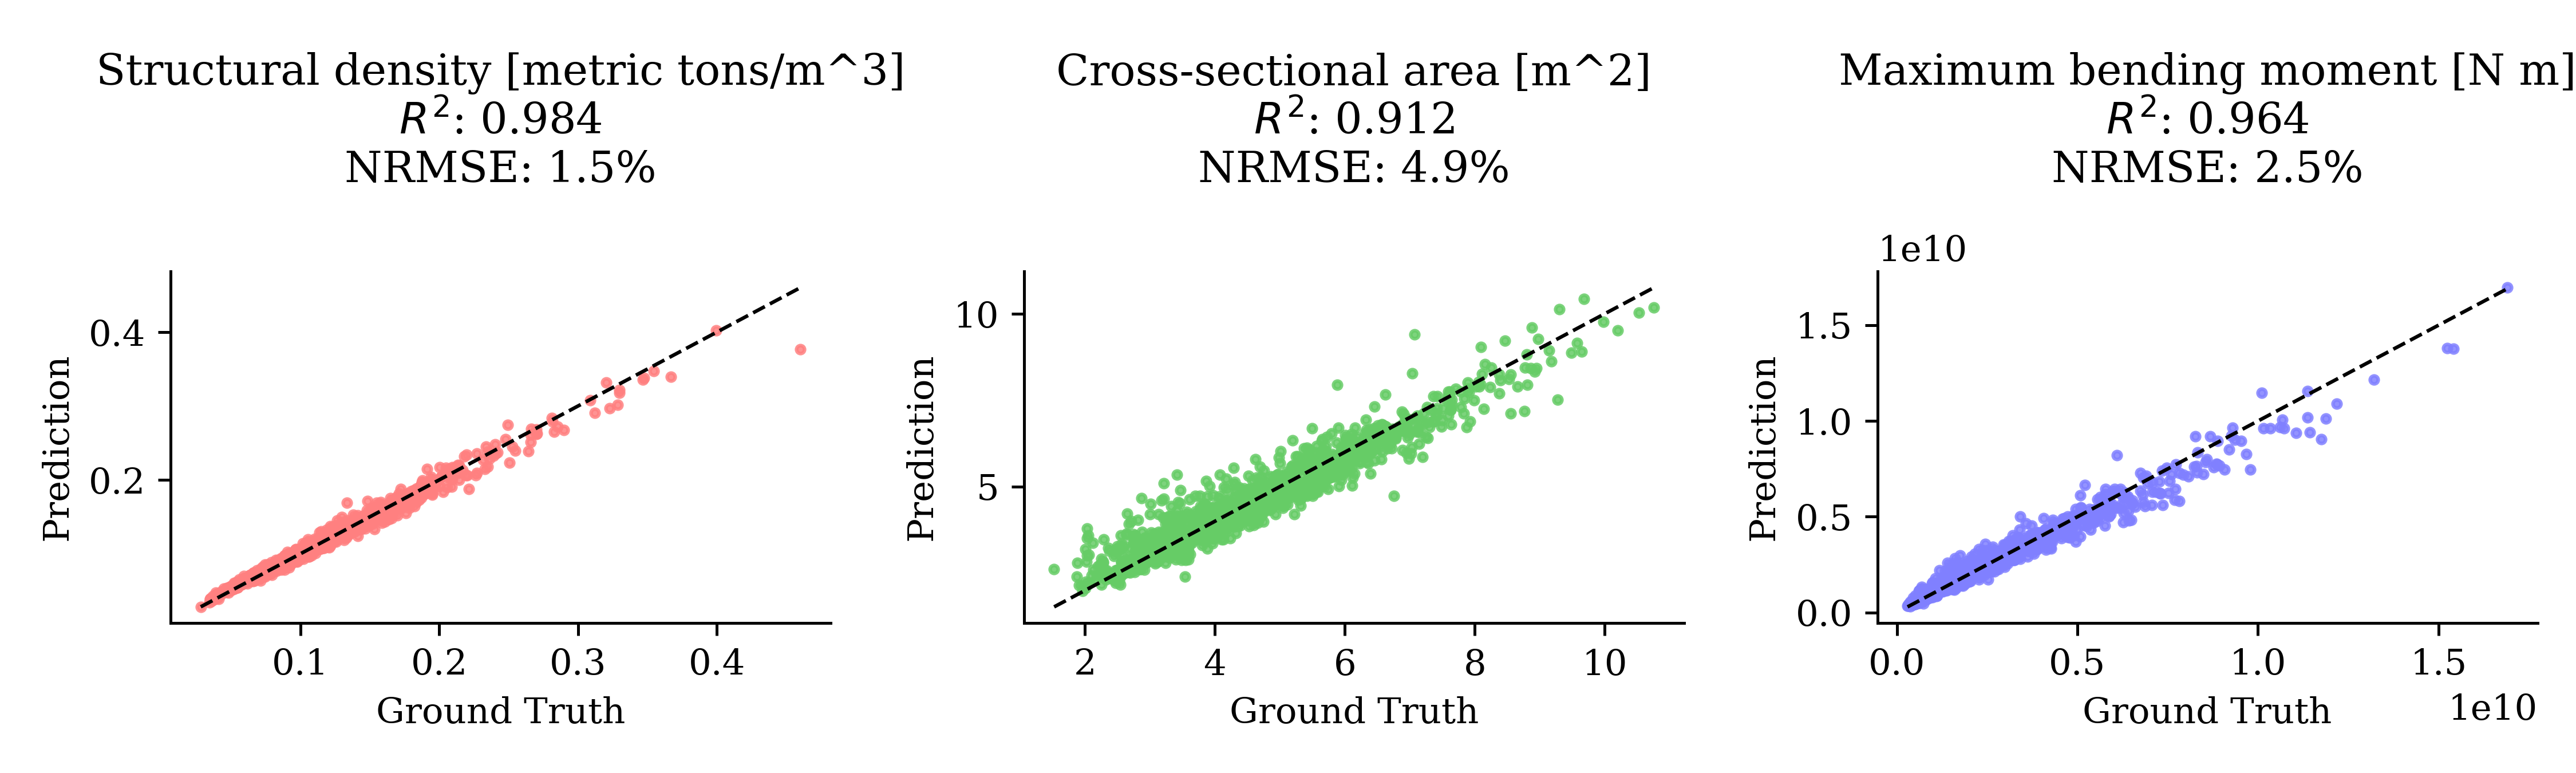

In [9]:


plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = '10' 

colors = [[1,.5,.5], [.4,0.8,.4], [.5,.5,1]]

#Make three subplots that show the regression versus ground truth for the test set and put the R2 score in the title
fig, axs = plt.subplots(1, 3, figsize=(10,3))

#plt.suptitle('Regression Accuracy For Surrogate Models')
for ax, color, i in zip(axs, colors, list(range(3))):
    
    ax.plot([Y_validation_physical[:,i].min(), Y_validation_physical[:,i].max()], [Y_validation_physical[:,i].min(), Y_validation_physical[:,i].max()], 'k--', alpha = 1, lw=1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.scatter(Y_validation_physical[:,i], output_validation_physical[:,i], color=color, marker='o', alpha=0.85, s=5 )
    ax.set_xlabel('Ground Truth')
    ax.set_ylabel('Prediction')
    ax.set_title(f'{y_labels[i]}\n' + r'$R^2$: ' + f'{R2[i]:.3f}' + '\n'+'NRMSE: ' + f'{(100*NRMSE[i]):.1f}%', pad=25)



plt.tight_layout()

plt.savefig('./Figures/Performance_Metrics_Regression.png', dpi=450)

plt.show()

## Now let's look at the Constraints ##


In [14]:
# First lets load the constraint thresholds and values and plot the constraint violations for the test set.

path = '/Users/noahbagazinski/Documents/MIT/Research/Ship_Structures/Dataset_Structures_V2_1'

constraint_thresholds = pd.read_csv(f"{path}/random_test_design_Constraint_Thresholds.csv")
constraint_evals = pd.read_csv(f"{path}/random_test_design_Constraint_Values.csv")

# Remove  Girder Thick

#constraint_diff = -(constraint_thresholds - constraint_evals)/(constraint_thresholds+1e-2) # Goal is to get negative
constraint_diff = constraint_thresholds - constraint_evals # Goal is to get negative



#clip to median+/- 2 sigma for each category
med = constraint_diff.median(axis=0)

sigma = constraint_diff.std(axis=0)
print(sigma.shape)

constraint_diff = constraint_diff.clip(med - 2*sigma, med + 2*sigma, axis=1)
print(constraint_diff.shape)

#first melt each dataframe to have columns for 'constraint_name', a column for index and a column for 'Value'
constraint_thresholds_melted = constraint_thresholds.melt(id_vars=None, var_name='Constraint', value_name='Value')
constraint_evals_melted = constraint_evals.melt(id_vars=None, var_name='Constraint', value_name='Value')

constraint_diff_melted = constraint_diff.melt(id_vars=None, var_name='Constraint', value_name='Value')




(25,)
(6050, 25)


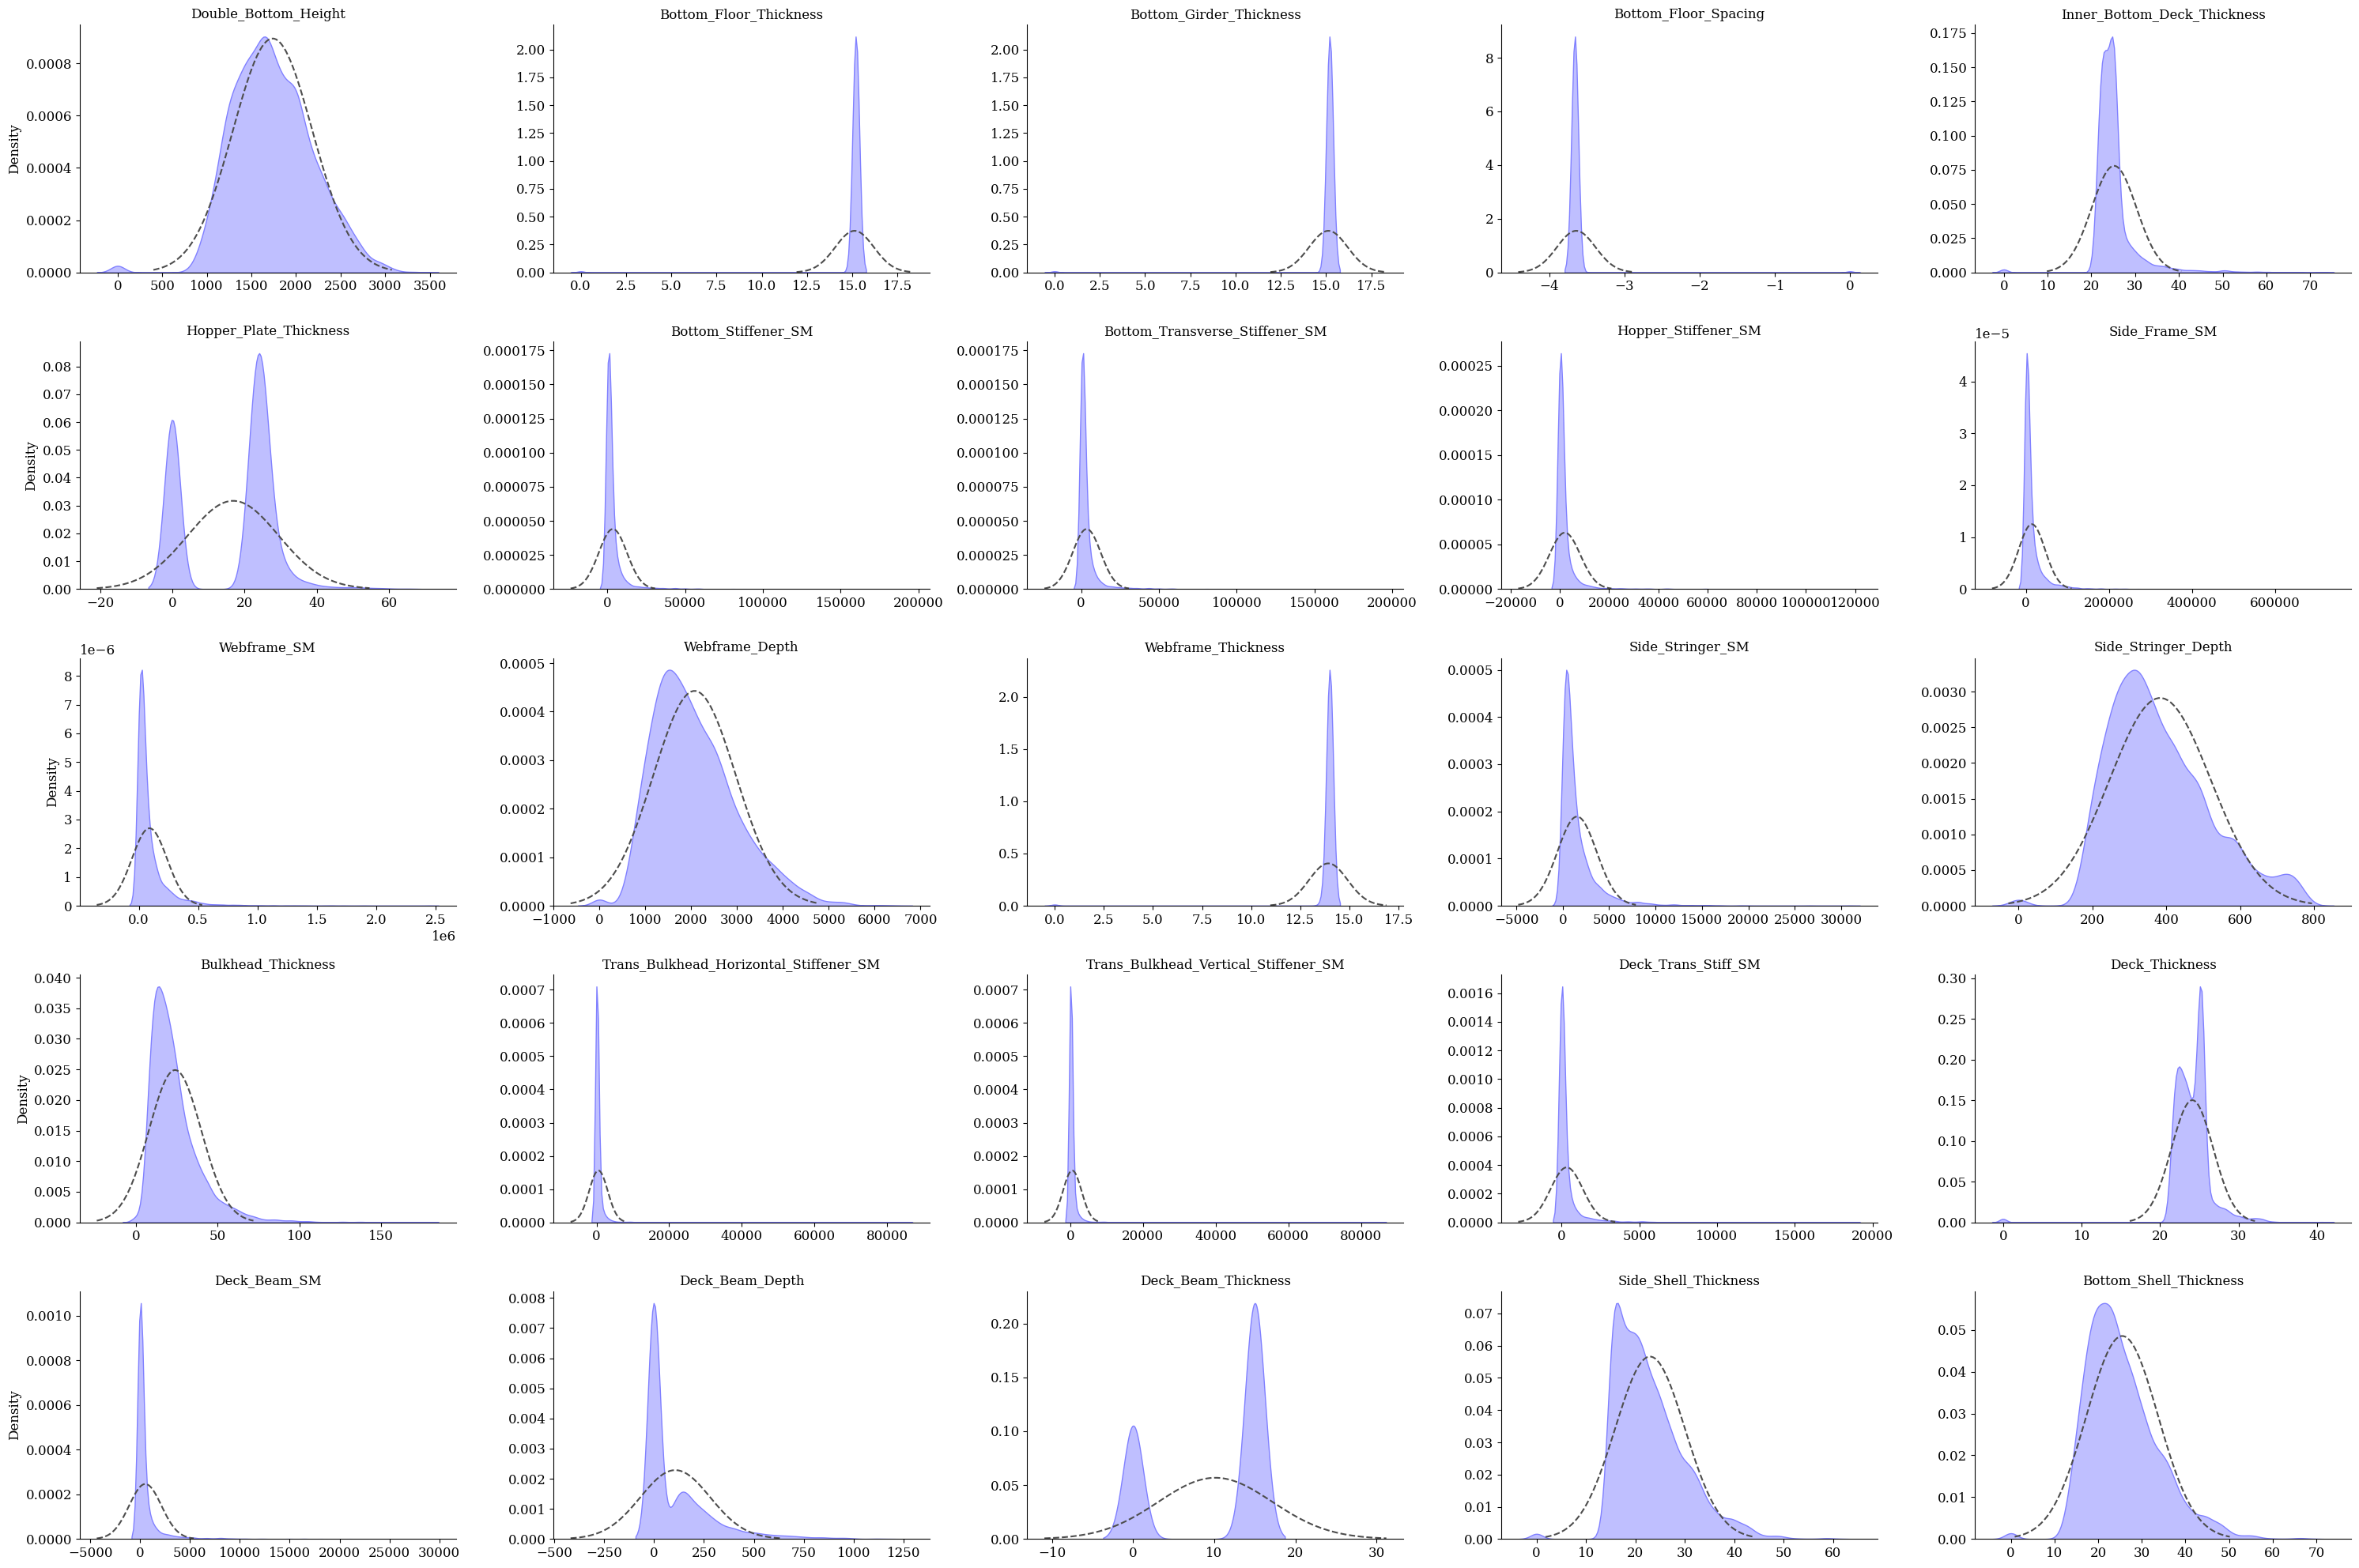

In [15]:
#plot the constraint thresholds as a kde with a normal curve in a facetgrid in a 6x4 grid 
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = '12' 



g = sns.FacetGrid(constraint_thresholds_melted, col='Constraint', sharex=False, sharey=False, height=4, aspect=1.5, col_wrap=5)

for ax, var in zip(g.axes.flatten(),constraint_thresholds_melted['Constraint'].unique()):
    sns.kdeplot(
        data=constraint_thresholds_melted[constraint_thresholds_melted["Constraint"] == var],
        x="Value",
        fill=True,
        ax=ax,
        color=[0.5,0.5,1.0],
        alpha=0.5
    )
    mu, std = constraint_thresholds_melted[constraint_thresholds_melted["Constraint"] == var]["Value"].mean(), constraint_thresholds_melted[constraint_thresholds_melted["Constraint"] == var]["Value"].std()
    x = np.linspace(mu - 3*std, mu + 3*std, 100)
    ax.plot(x, norm.pdf(x,mu,std), color=(0.3,0.3,0.3), linestyle='--', label=r'Normal Dist. Around $\mu, \sig$ of Data')

g.set_axis_labels("", "Density")
g.set_titles("{col_name}")
#plt.legend()
plt.tight_layout()
plt.show()


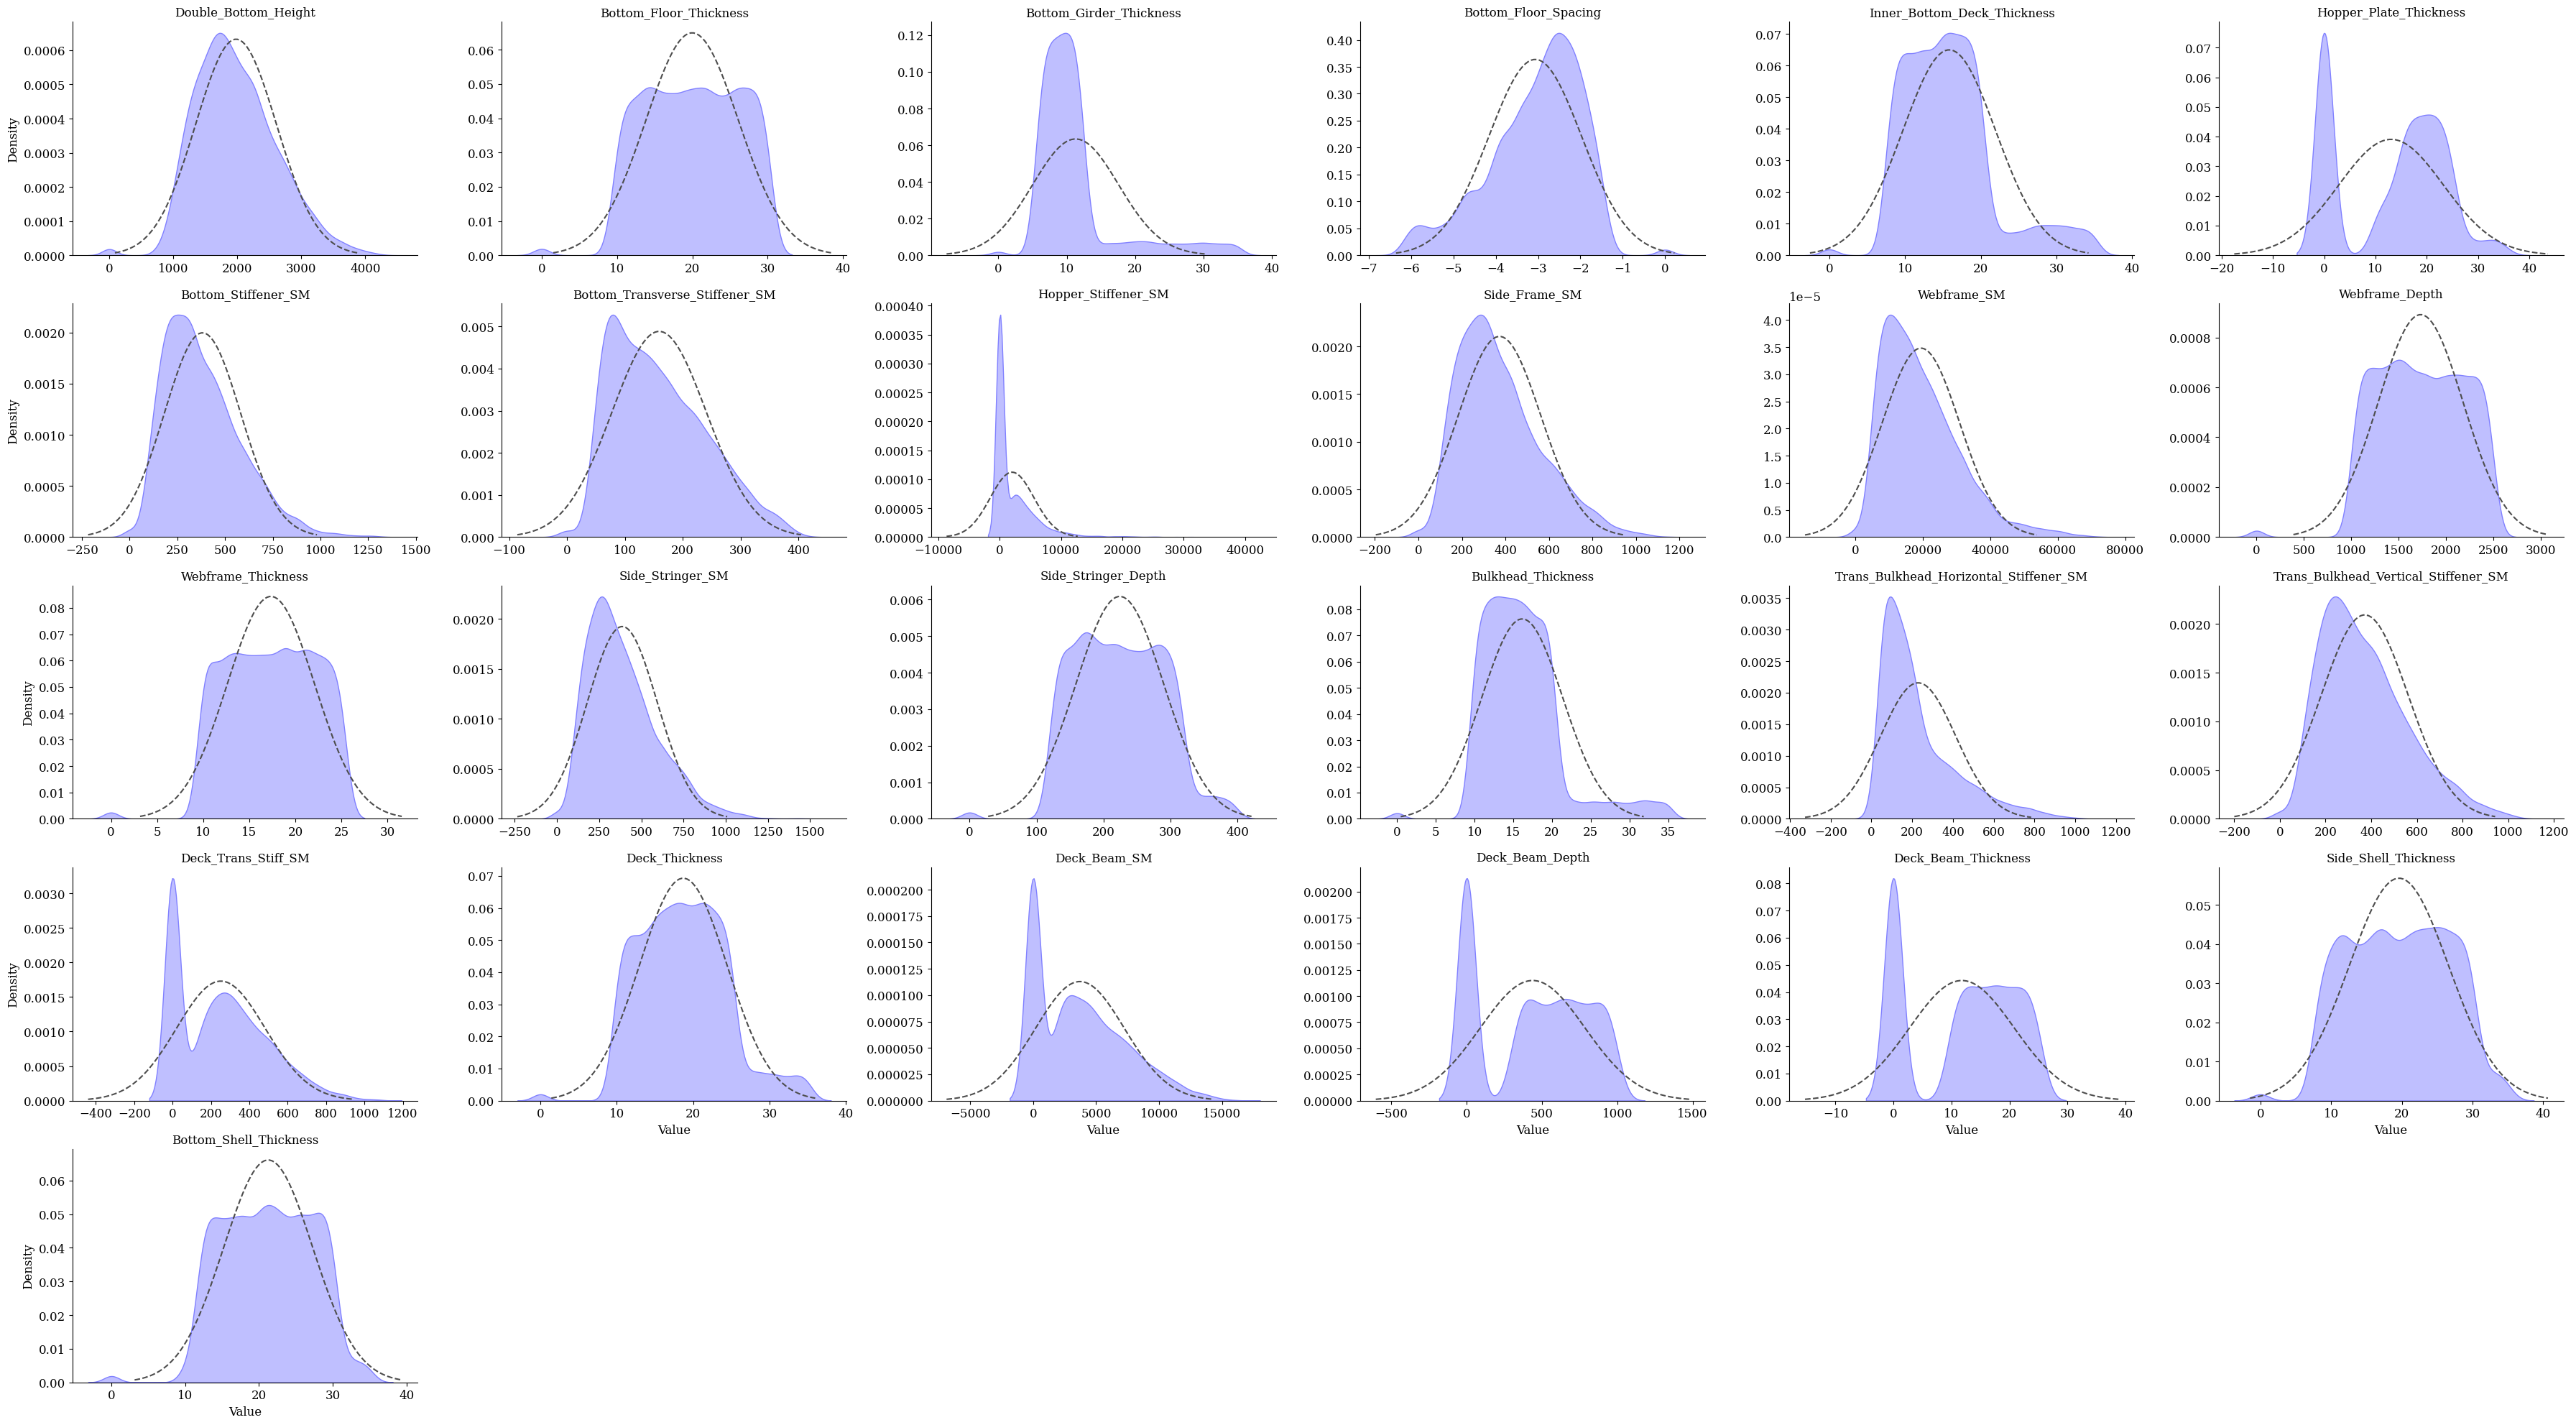

In [16]:
# Now lets repeat for the constraint evaluations. We can also plot the constraint violations by plotting the difference between the evaluation and the threshold for each constraint.
#plot the constraint thresholds as a kde with a normal curve in a facetgrid in a 6x4 grid 
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = '12' 



g = sns.FacetGrid(constraint_evals_melted, col='Constraint', sharex=False, sharey=False, height=4, aspect=1.5, col_wrap=6)

for ax, var in zip(g.axes.flatten(),constraint_evals_melted['Constraint'].unique()):
    sns.kdeplot(
        data=constraint_evals_melted[constraint_evals_melted["Constraint"] == var],
        x="Value",
        fill=True,
        ax=ax,
        color=[0.5,0.5,1.0],
        alpha=0.5
    )
    mu, std = constraint_evals_melted[constraint_evals_melted["Constraint"] == var]["Value"].mean(), constraint_evals_melted[constraint_evals_melted["Constraint"] == var]["Value"].std()
    x = np.linspace(mu - 3*std, mu + 3*std, 100)
    ax.plot(x, norm.pdf(x,mu,std), color=(0.3,0.3,0.3), linestyle='--', label=r'Normal Dist. Around $\mu, \sig$ of Data')

g.set_axis_labels("Value", "Density")
g.set_titles("{col_name}")
#plt.legend()
plt.tight_layout()
plt.show()



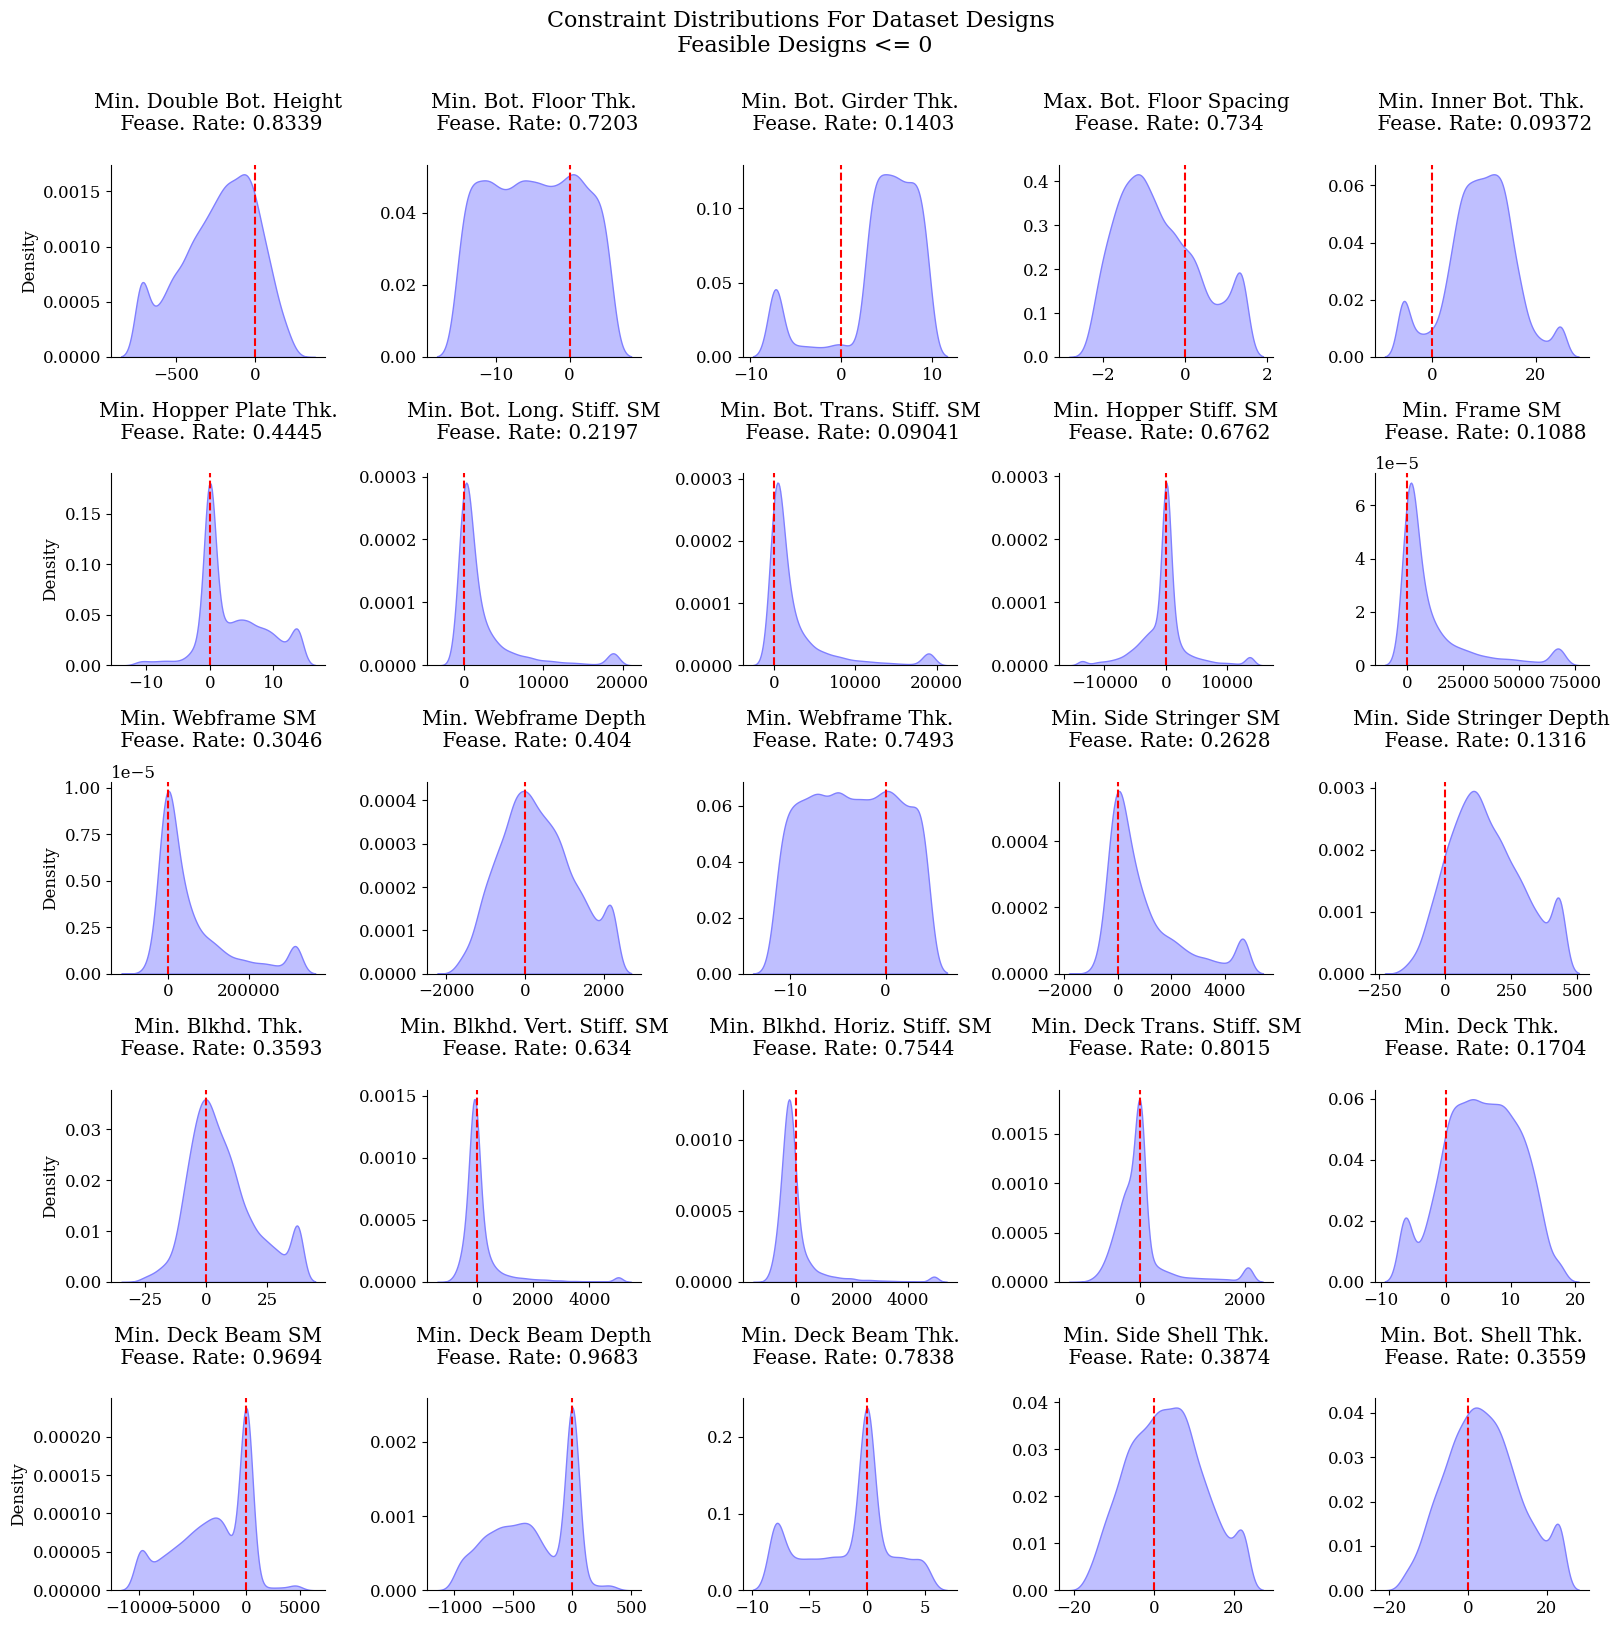

Max Feasebility Rate: 0.9694214876033058
Min Feasebility Rate: 0.09041322314049587
mean Feasebility Rate: 0.48394049586776866
Cumulative Feasibility Rate: 2.8581938275537087e-11


In [17]:
# Now let's plot the differene 

constraint_names = np.array([
    "Min. Double Bot. Height",
    "Min. Bot. Floor Thk.",
    'Min. Bot. Girder Thk.',
    "Max. Bot. Floor Spacing",
    "Min. Inner Bot. Thk.",
    "Min. Hopper Plate Thk.",
    "Min. Bot. Long. Stiff. SM",
    "Min. Bot. Trans. Stiff. SM",
    "Min. Hopper Stiff. SM",
    "Min. Frame SM",
    "Min. Webframe SM",
    "Min. Webframe Depth",
    "Min. Webframe Thk.",
    "Min. Side Stringer SM",
    "Min. Side Stringer Depth",
    "Min. Blkhd. Thk.",
    "Min. Blkhd. Horiz. Stiff. SM",
    "Min. Blkhd. Vert. Stiff. SM",
    "Min. Deck Trans. Stiff. SM",
    "Min. Deck Thk.",
    "Min. Deck Beam SM",
    "Min. Deck Beam Depth",
    "Min. Deck Beam Thk.",
    "Min. Side Shell Thk.",
    "Min. Bot. Shell Thk."
])

#print(constraint_diff_melted['Constraint'].unique())

   

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = '12'

g = sns.FacetGrid(constraint_diff_melted, col='Constraint', sharex=False, sharey=False, height=3.25, col_wrap=5)

for ax, var in zip(g.axes.flatten(),constraint_diff_melted['Constraint'].unique()):
    sns.kdeplot(
        data=constraint_diff_melted[constraint_diff_melted["Constraint"] == var],
        x="Value",
        fill=True,
        ax=ax,
        color=[0.5,0.5,1.0],
        alpha=0.5
    )
    mu, std = constraint_diff_melted[constraint_diff_melted["Constraint"] == var]["Value"].mean(), constraint_diff_melted[constraint_diff_melted["Constraint"] == var]["Value"].std()
    x = np.linspace(mu - 3*std, mu + 3*std, 100)
    #Plot a vertical line at x=0 to show the boundary between satisfied and violated constraints
    ax.axvline(x=0, color='r', linestyle='--', label='Constraint Boundary')
    #ax.plot(x, norm.pdf(x,mu,std), color=(0.3,0.3,0.3), linestyle='--', label=r'Normal Dist. Around $\mu, \sig$ of Data')
feas_rates = []
#Get percent of samples that satisfy each constraint and put it in the title of each subplot
for ax, var, i in zip(g.axes.flatten(),constraint_diff_melted['Constraint'].unique(), np.arange(len(constraint_diff_melted['Constraint'].unique()))):
    total_samples = len(constraint_diff_melted[constraint_diff_melted["Constraint"] == var])
    satisfied_samples = len(constraint_diff_melted[(constraint_diff_melted["Constraint"] == var) & (constraint_diff_melted["Value"] <= 0)])
    fease_rate = satisfied_samples / total_samples
    ax.set_title(constraint_names[i] + f'\n Fease. Rate: {fease_rate:.4}', pad=25)
    #print(f'{var}, Feasibility Rate: {fease_rate:.4}')
    feas_rates.append(fease_rate)

#Make super title
g.fig.suptitle('Constraint Distributions For Dataset Designs \n Feasible Designs <= 0 ', fontsize=16, y=1)

g.set_axis_labels("", "Density", fontsize=12)
#g.set_titles("{col_name}")
#plt.legend()
plt.tight_layout()
plt.savefig('./Figures/ABS_Cons.png', dpi=450)
plt.show()


print('Max Feasebility Rate:', max(feas_rates))
print('Min Feasebility Rate:', min(feas_rates))
print('mean Feasebility Rate:', np.mean(feas_rates))
# Cumulative Feasiblity Rate: 
print('Cumulative Feasibility Rate:', np.prod(feas_rates))



## Now let's train a constraint ML ##

we are going to train a model to predict contraint difference from parameters

In [10]:
# Load synchronized constraint targets for the same 6020 retained designs.
path = '/Users/noahbagazinski/Documents/MIT/Research/Ship_Structures/Dataset_Structures_V2_1'
error_idx = np.loadtxt(f"{path}/random_test_design_error_idx_All.csv", delimiter=',', dtype=int)

X_data = pd.read_csv(path + '/random_test_design_Parameters_All.csv')
constraint_thresholds = pd.read_csv(f"{path}/random_test_design_Constraint_Thresholds.csv")
constraint_evals = pd.read_csv(f"{path}/random_test_design_Constraint_Values.csv")
Y_data = constraint_thresholds - constraint_evals

# Remove the same CAD-failure rows used by the performance surrogate.
X_data = X_data.drop(index=error_idx)
Y_data = Y_data.drop(index=error_idx)

if X_data.shape[0] != Y_data.shape[0]:
    raise ValueError("Number of samples in X_data and Y_data do not match after removing error indices.")
if X_data.shape[0] != 6020:
    raise ValueError(f"Expected 6020 retained random designs, found {X_data.shape[0]}.")
if not np.array_equal(X_data.index.to_numpy(), retained_dataset_indices):
    raise ValueError("Constraint and performance targets do not share the same retained-row ordering.")

Y_s = Y_data.to_numpy()
X_s = X_data.to_numpy()
y_labels = Y_data.columns.to_numpy()

# Fit d_min for the logistic target transformation on training rows only.
min_Y_vals = Y_s[train_indices].min(axis=0)

def logistic_scaling(x, min_vals):
    min_values = np.asarray(min_vals, dtype=float)
    return 2.0 / (1.0 + np.exp(5.0 * x / (min_values + 1e-6))) - 1.0

In [11]:
# Transform constraint targets independently after the shared split.
Y_train = logistic_scaling(Y_s[train_indices], min_Y_vals)
Y_validation = logistic_scaling(Y_s[validation_indices], min_Y_vals)
Y_zeros = np.zeros((1, Y_s.shape[1]))

# Fit parameter standardization on constraint-training rows only.
X_param_scaler = StandardScaler()
X_param_scaler.fit(X_s[train_indices])
X_p_train = X_param_scaler.transform(X_s[train_indices])
X_p_validation = X_param_scaler.transform(X_s[validation_indices])

print(f"Constraint surrogate rows: {len(train_indices)} training, {len(validation_indices)} validation")


Constraint surrogate rows: 4816 training, 1204 validation


In [12]:
batch_size = 128

# Train the constraint surrogate on the shared training partition.
data_loader_1 = create_data_loader(X_p_train, Y_train, batch_size, random_seed=RANDOM_SEED)

# Reset the model-initialization seed immediately before constructing the network.
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
model_cons = MLP(X_p_train.shape[1], [256,256], Y_train.shape[1])
model_cons.to(device)
model_cons.train()

optimizer = torch.optim.Adam(model_cons.parameters(), lr=0.001)
criteria = nn.MSELoss()

num_epochs = 1000

for epoch in tqdm(range(num_epochs)):
    for X_batch, Y_batch in data_loader_1:
        X_batch = X_batch.to(device)
        Y_batch = Y_batch.to(device)
        optimizer.zero_grad()
        output = model_cons(X_batch)
        loss = criteria(output, Y_batch)
        loss.backward()
        optimizer.step()
    if(epoch % 500 == 0):
        print(f'Epoch {epoch+1}/{num_epochs}, Loss: {loss.item()}')


# Evaluate every row in the untouched validation partition.
X_p_validation_tensor = torch.tensor(X_p_validation).float().to(device)
model_cons.eval()
with torch.no_grad():
    constraint_output_validation = model_cons(X_p_validation_tensor).cpu().numpy()
Y_validation_scaled = Y_validation


Epoch 1/1000, Loss: 0.19492340087890625
Epoch 501/1000, Loss: 0.03141165152192116


In [13]:
# Calculate metrics on every validation row; no predictions are filtered.
from sklearn.metrics import r2_score

number_of_constraint_outputs = Y_validation_scaled.shape[1]
R2 = np.zeros(number_of_constraint_outputs)
MSE = np.zeros(number_of_constraint_outputs)
RMSE = np.zeros(number_of_constraint_outputs)
NRMSE = np.zeros(number_of_constraint_outputs)
validation_true_range = np.zeros(number_of_constraint_outputs)

for i in range(number_of_constraint_outputs):
    true_values = Y_validation_scaled[:, i]
    predicted_values = constraint_output_validation[:, i]
    R2[i] = r2_score(true_values, predicted_values)
    MSE[i] = np.mean((true_values - predicted_values)**2)
    RMSE[i] = np.sqrt(MSE[i])
    validation_true_range[i] = true_values.max() - true_values.min()
    NRMSE[i] = RMSE[i] / validation_true_range[i]

constraint_validation_metrics = pd.DataFrame({
    'output_index': np.arange(number_of_constraint_outputs),
    'output_label': y_labels,
    'training_rows': len(train_indices),
    'validation_rows': len(validation_indices),
    'random_seed': RANDOM_SEED,
    'training_d_min': min_Y_vals,
    'r2': R2,
    'mse': MSE,
    'rmse': RMSE,
    'nrmse': NRMSE,
    'nrmse_denominator_true_validation_range': validation_true_range
})
constraint_validation_metrics.to_csv(
    VALIDATION_ARTIFACT_DIR / 'Constraint_Surrogate_Validation_Metrics.csv',
    index=False,
    float_format='%.17g'
)
print(constraint_validation_metrics.to_string(index=False))


 output_index                           output_label  training_rows  validation_rows  random_seed  training_d_min       r2      mse     rmse    nrmse  nrmse_denominator_true_validation_range
            0                   Double_Bottom_Height           4816             1204           41    -1381.257261 0.930781 0.007536 0.086813 0.062732                                 1.383865
            1                 Bottom_Floor_Thickness           4816             1204           41      -14.800000 0.977200 0.007076 0.084121 0.049710                                 1.692220
            2                Bottom_Girder_Thickness           4816             1204           41      -19.800000 0.966673 0.008550 0.092465 0.051137                                 1.808180
            3                   Bottom_Floor_Spacing           4816             1204           41       -2.305189 0.971568 0.011414 0.106838 0.054048                                 1.976721
            4            Inner_Bottom_Deck_Th

In [14]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = '12'

constraint_display_names = {
    'Double_Bottom_Height': 'Min. Double Bot. Height',
    'Bottom_Floor_Thickness': 'Min. Bot. Floor Thk.',
    'Bottom_Girder_Thickness': 'Min. Bot. Girder Thk.',
    'Bottom_Floor_Spacing': 'Max. Bot. Floor Spacing',
    'Inner_Bottom_Deck_Thickness': 'Min. Inner Bot. Thk.',
    'Hopper_Plate_Thickness': 'Min. Hopper Plate Thk.',
    'Bottom_Stiffener_SM': 'Min. Bot. Long. Stiff. SM',
    'Bottom_Transverse_Stiffener_SM': 'Min. Bot. Trans. Stiff. SM',
    'Hopper_Stiffener_SM': 'Min. Hopper Stiff. SM',
    'Side_Frame_SM': 'Min. Frame SM',
    'Webframe_SM': 'Min. Webframe SM',
    'Webframe_Depth': 'Min. Webframe Depth',
    'Webframe_Thickness': 'Min. Webframe Thk.',
    'Side_Stringer_SM': 'Min. Side Stringer SM',
    'Side_Stringer_Depth': 'Min. Side Stringer Depth',
    'Bulkhead_Thickness': 'Min. Blkhd. Thk.',
    'Trans_Bulkhead_Horizontal_Stiffener_SM': 'Min. Blkhd. Horiz. Stiff. SM',
    'Trans_Bulkhead_Vertical_Stiffener_SM': 'Min. Blkhd. Vert. Stiff. SM',
    'Deck_Trans_Stiff_SM': 'Min. Deck Trans. Stiff. SM',
    'Deck_Thickness': 'Min. Deck Thk.',
    'Deck_Beam_SM': 'Min. Deck Beam SM',
    'Deck_Beam_Depth': 'Min. Deck Beam Depth',
    'Deck_Beam_Thickness': 'Min. Deck Beam Thk.',
    'Side_Shell_Thickness': 'Min. Side Shell Thk.',
    'Bottom_Shell_Thickness': 'Min. Bot. Shell Thk.'
}
constraint_plot_labels = [constraint_display_names[label] for label in y_labels]

# Plot all 25 canonical constraint outputs on the full validation partition.
fig, axs = plt.subplots(5, 5, figsize=(20, 15))
axs = axs.flatten()

for i in range(number_of_constraint_outputs):
    true_values = Y_validation_scaled[:, i]
    predicted_values = constraint_output_validation[:, i]
    comparison_min = min(true_values.min(), predicted_values.min())
    comparison_max = max(true_values.max(), predicted_values.max())
    axs[i].plot([comparison_min, comparison_max], [comparison_min, comparison_max], 'k--', alpha=1, lw=1)
    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)
    axs[i].scatter(true_values, predicted_values, color=[0.5,0.5,1.0], marker='o', alpha=0.85, s=5, label='Constraint predictions')
    axs[i].axvline(x=0, color='r', linestyle='--', label='Constraint boundary')
    axs[i].axhline(y=0, color='r', linestyle='--', label='Predicted constraint boundary')
    axs[i].set_xlabel('Ground truth')
    axs[i].set_ylabel('Prediction')
    axs[i].set_title(
        f'{constraint_plot_labels[i]}\n' + r'$R^2$: ' + f'{R2[i]:.3f}\n' + f'NRMSE = {(NRMSE[i] * 100):.1f}%',
        pad=25
    )

plt.tight_layout()
plt.savefig(VALIDATION_ARTIFACT_DIR / 'ABS_Cons_Reg.png', dpi=450)
plt.show()

In [23]:
# Lets extract the designs that satisfy all constraints and plot the distribution of their structural properties compared to the full dataset

con_vals = pd.read_csv(f"{path}/random_test_design_Constraint_Values.csv")
con_thresh = pd.read_csv(f"{path}/random_test_design_Constraint_Thresholds.csv")
con_diff = con_thresh - con_vals


#cons_diff = con_diff.drop(index=error_idx)
#reindex
#cons_diff = cons_diff.reset_index(drop=True)
# Get indices of designs that satisfy all constraints

cons = np.sum((con_diff <= 0), axis=1) # Number of constraints satisfied for each design

feas_idx = np.where(cons == 25)[0] # Indices of designs that satisfy all 25 constraints

print(f"Number of error indices: {len(error_idx)}")
#Remove error indices from feas_idx
feas_idx = [idx for idx in feas_idx if idx not in error_idx]

print(f"Number of feasible designs: {len(feas_idx)}")

print("Feasible indices:", feas_idx)

# NO FULLY FEASIBLE DESIGNS IN THIS DATASET!

#Find 25 designs with most constraints satisfied

top_feas_idx = np.argsort(cons)[-(25 + len(error_idx)):]


top_feas_idx = [idx for idx in top_feas_idx if idx not in error_idx]
print("Top 25 indices with most constraints satisfied after removing error indices:", top_feas_idx)


Number of error indices: 30
Number of feasible designs: 0
Feasible indices: []
Top 25 indices with most constraints satisfied after removing error indices: [5717, 5607, 5112, 5575, 5782, 5395, 5523, 6023, 5984, 5668, 853, 5783, 6014, 5706, 5030, 5091, 5657, 6022, 5440, 5121, 5264, 5563, 5330, 5133, 5656]


# Now Let's Set Up Design Generation #

In [24]:

n_constr = len(Y_zeros[0])

parameter_ranges = pd.read_csv('/Users/noahbagazinski/Documents/MIT/Research/Ship_Structures/StructuralParameterList_V2_Updated_Ranges.csv')
xl = parameter_ranges['LL'].to_numpy(dtype=float)
xu = parameter_ranges['UL'].to_numpy(dtype=float)

# R_b is defined as 0.75--1.0 times Db/1000 instead of having direct LL/UL values.
xl[4] = parameter_ranges.loc[4, 'Strategic_LL']*xl[6]/1000.0
xu[4] = parameter_ranges.loc[4, 'Strategic_UL']*xu[6]/1000.0

# We want to adjust the limits of L_3h, B, and D
LOA = 250 #for reference


param_idx_bit = np.array([27,31,35,39,43,47,51,56,74,79,86,91,96, 100, 104,105,111,115,116]) #The indices of the parameters that are boolean values (T or C)
param_idx_cat = np.array([57,58,59]) #The indices of the parameters that are categorical values (Tanker, Container, Bulk Carrier)
param_idx_int = np.array([15,16,17,18,19,20,21,22,70, 75,82,87,92, 106]) #The indices of the parameters that are integers (number of stiffeners)

param_idx_plate_thicknesses = np.array([7,8,9,10,11,12,23,29,33,37,41,45,49,52,54,62,65,68,69,72,77,80,81,84,89,94,98,102,107,109,113])

param_idx_brackets = np.array([60,61,63,64]) #The indices of the parameters that are for the brackets -tanker and bulk carrier
param_idx_container = np.array([66,67,68,69,70,71,72,73,74,75,76,77,78,79]) #The indices of the parameters that are for the container step
param_idx_bulkcarrier = np.array([80,81,82,83,84,85,86,87,88,89,90,91]) #The indices of the parameters that are for the bulk carrier


def clean_Struct_Params(param_set):

    params = param_set.copy().astype(float) #Make sure we are working with floats to avoid issues with the int and bool conversions below

    for i in range(len(params)):
        
        params[i] = np.clip(params[i], xl,xu) #Clip all values to be between min and max values for each parameter
        
        params[i, param_idx_bit] = params[i, param_idx_bit] >= 0.5
        params[i, param_idx_int] = np.int32(params[i, param_idx_int]+0.5)
        params[i, param_idx_plate_thicknesses] = np.int32(params[i, param_idx_plate_thicknesses]+0.5)


        if params[i,6] < 1000.0*params[i,4]: #If the double bottom height is less than the bilge radius, set the bilge radius to Db height
                params[i,4] = params[i,6]/1000.0

                
        #Get argmax of categorical values to assign ship class
        ship_class = np.argmax(params[i,param_idx_cat])
        params[i,57:60] = 0 #Reset ship class values
        params[i,57 + ship_class] = 1 #Set the ship class to the argmax value


        #Check Categorical Values:
        if params[i,57] == 1: #Tanker
            params[i,param_idx_bulkcarrier] = 0
            params[i,param_idx_container] = 0
        elif params[i,58] == 1:
            params[i,param_idx_bulkcarrier] = 0
            params[i,param_idx_brackets] = 0
        elif params[i,59] == 1:
            params[i,param_idx_container] = 0
        
        #Check Inner Side wall Thickness
        if params[i,12] < 10.0:
            params[i,12] = 0
        else: 
            params[i,50] = 0 # If there is an inner side shell, no webframe flange cap. 
        #Chek Longitudinal Bulkhead
        if params[i,105] <= 0.5:
            params[i,105] = 0
            params[i,106:116] = 0.0
        elif params[i,106] <= 0.5:
            params[i,105:116] = 0.0
        else:
            params[i,105] = 1

        #check hatch openings
        if params[i,116] <= 0.5 or params[i,117] < 1e-2 or params[i,118] < 1e-2:
            params[i,116] = 0
            params[i,117:120] = 0.0


        else:
            params[i,116] = 1
    
    return params

## Let's Try Stochastic Gradient Langevin Dynamics ##

Let's optimize a structure for Weight and Bending Stress

In [ ]:
sigma = 0.001
#sigma = 0.01
alpha = 0.1

XL = torch.from_numpy(X_param_scaler.transform(xl.reshape(1,-1))).float().to(device)
XU = torch.from_numpy(X_param_scaler.transform(xu.reshape(1,-1))).float().to(device)


xlen = len(X_data.columns)

def optimize_step(X_t, sigma=sigma, alpha=alpha):
    #X_c = clean_Struct_Params(X_c)

    #X_c = feature_engineer_X(X_c)
    #X_c = X_param_scaler.transform(X_c)

    #X_t = torch.from_numpy(X_c).to(device).float()

    # Weight the different objectives from 0 to 1 linspace
    #weights = torch.tensor(np.linspace(0, 1, len(X_t))).float().to(device)

    with torch.enable_grad():
        
        X_t.requires_grad_(True)
        F = model_1(X_t)
        G = model_cons(X_t)+0.7 # We want to beat the constraint boundary by 0.1 to ensure we get feasible solutions

        F_step = torch.sum(F[:,0]) - sum(F[:,2]) # We want to minimize weight and maximize bending moment, so we take the negative of the bending moment prediction for the second objective 
        
        #Try relu weighting
        G_step = torch.sum(nn.ReLU()(G))# We only want to prioritize satisfying the constraints that are violated, so we take the leaky relu of the constraint violations to only get positive values for violated constraints

        #G_step = torch.sum(G)
        '''
        if G.any() > 0: # If any constraints are violated, we want to prioritize satisfying the constraints over optimizing the objectives
            step = -0.2*F_step - G_step 
        else:
            step = -F_step + 0.2*G_step

        '''
        step = -G_step-0.1*F_step
        #step = -G_step
        step.sum().backward()

        #print("Step:", step.item())
        #print(X_t.grad)
        
        X_out = X_t + alpha*X_t.grad + sigma*torch.randn_like(X_t)

    X_out = X_out.detach()

    #now inverse transform the scaled X_s back to the original scale and only return original parameters (not the feature engineered ones)
    #X_s = X_param_scaler.inverse_transform(X_s)
    
    #X_s = X_s[:, 0:xlen] # Only return the original parameters

    return X_out


def Stochastic_Gradient_Langevin_Dynamics(X_init, seed_interp, num_steps=100, sigma=sigma, alpha=alpha):
    X_sgld = X_init.copy()

    X_sgld = X_param_scaler.transform(X_sgld)

    if seed_interp:
        #Randomly interpolate between the initial population
        print("Using seed interpolation for optimization")
        A = np.random.choice(len(X_sgld), size=(len(X_sgld), 2), replace=True)
        b = np.random.rand(len(X_sgld), 1)
        X_sgld = X_sgld[A[:,0]]*b + X_sgld[A[:,1]]*(1-b)
        
    X_sgld = torch.from_numpy(X_sgld).to(device).float()

    for i in tqdm(range(num_steps)):
        X_sgld = optimize_step(X_sgld, sigma=sigma, alpha=alpha)
        X_sgld = torch.clip(X_sgld, XL, XU) # Clip the values to the original bounds

    X_sgld = X_sgld.detach().cpu().numpy()
    X_sgld = X_param_scaler.inverse_transform(X_sgld)
    X_sgld = clean_Struct_Params(X_sgld)
    return X_sgld


### Now let's run a gradient descent optimization and save the results

In [ ]:
#initialize by grabbing random members of the dataset 
opt_path = '/Users/noahbagazinski/Documents/MIT/Research/Ship_Structures/Optimization_Results'
opti_id = 'SGD_Opt_1'
pop_size = 100

X_data = pd.read_csv(path + '/random_test_design_Parameters_All.csv')



A = np.random.choice(top_feas_idx, size=pop_size, replace=True)

print("Initial designs for SGD:", A)

X_init = X_data.values[A,:].astype(float)
#X_init = clean_Struct_Params(X_init)


X_opt = Stochastic_Gradient_Langevin_Dynamics(X_init, seed_interp=True, num_steps=100, sigma=sigma, alpha=alpha)

F_opt = model_1(torch.from_numpy(X_param_scaler.transform(X_opt)).to(device).float()).detach().cpu().numpy()
F_opt = Y_scaler_obj.inverse_transform(F_opt)

G_opt = model_cons(torch.from_numpy(X_param_scaler.transform(X_opt)).to(device).float()).detach().cpu().numpy()
#G_opt = Y_scaler0.inverse_transform(Y_scaler1.inverse_transform(G_opt))

#Save the results to a csv file
opt_results = pd.DataFrame(X_opt, columns=X_data.columns)
opt_results.to_csv(f"{opt_path}/{opti_id}_X_Results.csv", index=False)

opt_results_F = pd.DataFrame(F_opt[:,[0,2]], columns=['Structural Weight [kg]', 'Max Bending Moment [Nm]'])
opt_results_F.to_csv(f"{opt_path}/{opti_id}_F_Results.csv", index=False)

opt_results_G = pd.DataFrame(G_opt, columns=y_labels)
opt_results_G.to_csv(f"{opt_path}/{opti_id}_G_Results.csv", index=False)

Initial designs for SGD: [5782 5783 5717 5121 5112 5717 6023 5264 5091 6023 5656 5112 5264 5121
 5717 6022 5563 5133 5657 5030 5440 5706 5112 5984 5091 5575 5030 5783
 5575 5575 5656 5330  853 5330 5330 5607 6022 6022 5121 5563 5706 5112
 5091 5782 5133 5563 5607 6014 5395 5091 5717 5782 5706 5717 5575 5783
 5668 5656 5030 5030 5984 5668 5706 6022 5706 5112 5668 5782 5717 5440
 5783 5717 5330 5030 5440 5133 5523 6022 5112 5782 5657 5657 5030 5121
 5330 6014 6022 5133  853 5264 5121 5656 5091 5657 5984 5330 5783  853
 5563 6022]
Using seed interpolation for optimization


100%|██████████| 100/100 [00:00<00:00, 441.58it/s]


## Run Neural Repair Generation ##

Set `num_samples` in the following cell to generate that many repaired designs. Constraint-violating seeds are sampled from the valid training data, while the complete valid dataset remains available as the donor pool.

In [ ]:
import Neural_Repair as NR


# Set the number of new repaired designs to generate.
num_samples = 100
neural_repair_seed = 42
neural_repair_id = 'Neural_Repair_1'


# Rebuild an aligned donor dataset because the preceding optimization cell
# reloads X_data without removing the designs that failed evaluation.
X_repair_donors = pd.read_csv(
    f"{path}/random_test_design_Parameters_All.csv"
).drop(index=error_idx)

G_repair_donors = Y_cls.loc[X_repair_donors.index].astype(bool)


# Generate exactly num_samples repaired designs. The full valid dataset is
# retained as the donor pool, independent of the requested output size.
X_neural_repair = NR.Neural_Repair(
    X=X_repair_donors,
    G=G_repair_donors,
    CV=model_cons,
    X_param_scaler=X_param_scaler,
    num_samples=num_samples,
    top_k_parameters=8,
    max_repair_attempts=3,
    random_seed=neural_repair_seed,
)


# Evaluate the generated designs with the same constraint model used during
# repair so the predicted constraint values can be inspected and saved.
X_neural_repair_scaled = X_param_scaler.transform(
    X_neural_repair.to_numpy()
)
X_neural_repair_tensor = torch.as_tensor(
    X_neural_repair_scaled,
    dtype=next(model_cons.parameters()).dtype,
    device=device,
)

with torch.no_grad():
    G_neural_repair_values = model_cons(
        X_neural_repair_tensor
    ).cpu().numpy()

G_neural_repair = pd.DataFrame(
    G_neural_repair_values,
    columns=y_labels,
)


# Save outputs using the same naming convention as the optimization stage.
X_neural_repair.to_csv(
    f"{opt_path}/{neural_repair_id}_X_Results.csv",
    index=False,
)
G_neural_repair.to_csv(
    f"{opt_path}/{neural_repair_id}_G_Results.csv",
    index=False,
)

num_predicted_feasible = (G_neural_repair <= 0.0).all(axis=1).sum()
print(f"Generated {len(X_neural_repair)} repaired designs.")
print(
    f"Predicted feasible designs: {num_predicted_feasible}/"
    f"{len(X_neural_repair)}"
)

X_neural_repair.head()

## Now Let's Reevaluate the Optimized Structures ##

Run Rhino Script for evaluating the designs:

NSGA 2
notes: Population of 1000 for 1500 generations took 152 seconds
Pop 1000 for 100 gens took 10.5 seconds

Pop 100 gen 200 t =1.5 sec


SGD
25 samples for 10k steps 11 sec


In [25]:
#opti_id = 'SGD_Opt_1_design'
opti_id = 'diverse_dataset_repair_100_004_design'

#opt_file_path = '/Users/noahbagazinski/Documents/MIT/Research/Ship_Structures/Optimization_Results'
opt_file_path = '/Users/noahbagazinski/Documents/MIT/Research/Ship_Structures/equation_repair_pipeline/experiments/diverse_dataset_repair_100_004/structures'
num_samples = 100

#merge_data(file_path, np.array(['0_24']), opti_id) #999', '4000_4999', '5000_5006']))

format_training_data(opt_file_path, opti_id, num_samples)




    

No error indices found for diverse_dataset_repair_100_004_design.


  4%|▍         | 4/100 [00:00<00:02, 37.86it/s]

{'Trans_Bulkheads': 14.542512365511785, 'Webframes': 1.6158347067497978, 'Frames': 0.3231669384917959, 'Deck_Girders': 3.552713678800501e-15, 'Deck_Stringers': 8.049116928532385e-16, 'Bottom_Girders': 1.4208335858063388, 'Bottom_Stringers': 0.2029762265437627, 'Side_Stringers': 0.4523622391500014, 'Trans_Bulkhead_Horizontal_Stiffeners': 1.1657341758564144e-15, 'Trans_Bulkhead_Vertical_Stiffeners': 0.608928679631288, 'Hopper_Stiffeners': 0.0}
{'Trans_Bulkhead_Thickness': 31.0, 'Bottom_Floor_Thickness': 20.0, 'Bottom_Girder_Thickness': 26.0, 'Bottom_Stiffener_Thickness': 11.14950883, 'Bottom_Stiffener_Depth': 0.2825619784900319, 'Bottom_Stiffener_flange_width': 0.178960978, 'Bottom_Transverse_Stiffener_Thickness': 11.0, 'Bottom_Transverse_Stiffener_Depth': 0.2881503865626112, 'Bottom_Transverse_Stiffener_flange_width': 0.0, 'Webframe_Depth': 1.67381625421791, 'Webframe_thickness': 14.0, 'Webframe_flange_width': 0.3231669384917959, 'N_frames': 4, 'Frame_Depth': 0.2980087872821021, 'Frame_

100%|██████████| 100/100 [00:01<00:00, 64.03it/s]
/var/folders/6c/7y2jzhfd6t3750c02xt1gxl00000gn/T/ipykernel_80085/4101182647.py:122: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  constraint_thresholds = constraint_thresholds.fillna(0.0)
/var/folders/6c/7y2jzhfd6t3750c02xt1gxl00000gn/T/ipykernel_80085/4101182647.py:123: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  constraint_evals = constraint_evals.fillna(0.0)


## Let's plot three things: 

1) NN Predictions vs Ground Truth for Optimized Results
2) Range of Objective Function Values for Optimized vs Dataset
3) Range of Constraints for Optimized vs Dataset

In [26]:
# First plot Predicted vs Ground Truth for the test set for the surrogate model with R2 score in the title

#Load X Data info: 
path = '/Users/noahbagazinski/Documents/MIT/Research/Ship_Structures/Dataset_Structures_V2_1'
error_idx = np.loadtxt(f"{path}/random_test_design_error_idx_All.csv", delimiter=',', dtype=int)
try:
    error_idx_opt = np.loadtxt(f"{opt_file_path}/{opti_id}_error_idx_All.csv", delimiter=',', dtype=int)
except:
    error_idx_opt = np.array([])
#Load y Data:
Y_data = pd.read_csv(path + '/random_test_design_Structural_Properties.csv')
Y_data_opt = pd.read_csv(opt_file_path + f'/{opti_id}_Structural_Properties.csv')

#Y_data = Y_data.drop(index=error_idx)
#Y_data_opt = Y_data_opt.dropna()


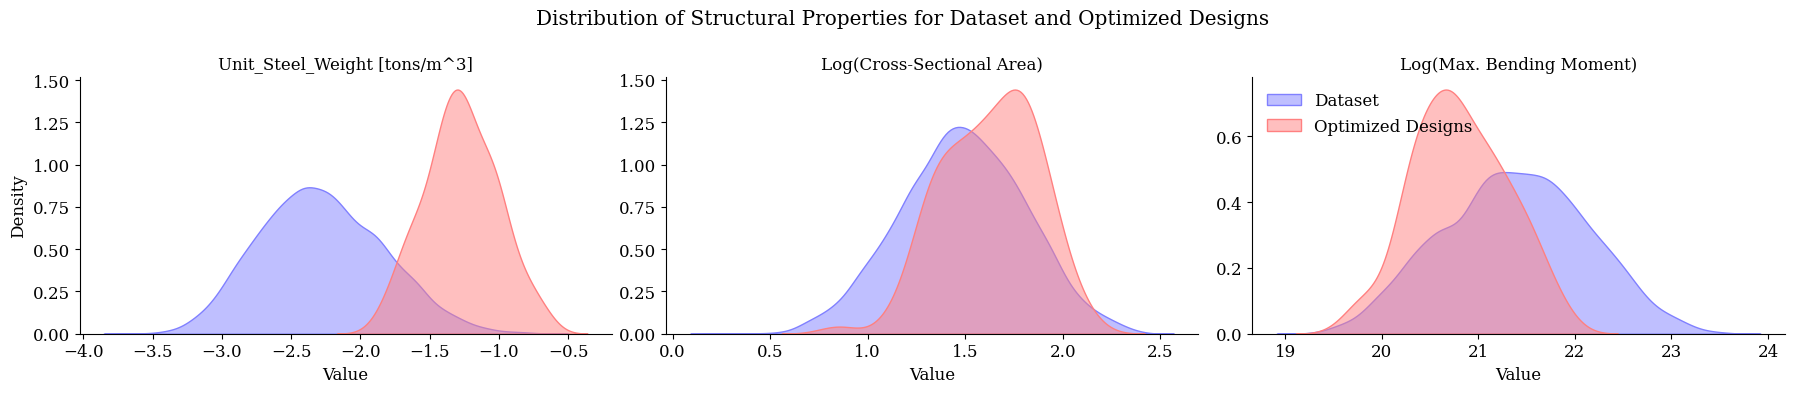

In [27]:
#Let's plot a kde of each of the Y_data columns

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = '12' 

colors = [[1,.5,.5], 
          [.4,.8,.4], 
          [.5,.5,1],
          [1,.5,.5],
          [.4,.8,.4],
          [.5,.5,1]]

idx = [2, 6, 11]  # Indices of the columns to plot
columns_to_plot = df_columns[idx]

Y_data_subset = Y_data.melt(id_vars=None, value_vars=columns_to_plot, var_name='Structural Property', value_name='Val')
Y_data_subset['Val'] = np.log(Y_data_subset['Val'])

Y_data_opt_subset = Y_data_opt.melt(id_vars=None, value_vars=columns_to_plot, var_name='Structural Property', value_name='Val')
Y_data_opt_subset['Val'] = np.log(Y_data_opt_subset['Val'])


#Rename the columns in Y_data_subset for clarity
Y_data_subset['Structural Property'] = Y_data_subset['Structural Property'].replace({
    r'Unit_Steel_Weight [tons/$m^3$]': 'Log(Unit Steel Weight)',
    r'Cross_Sectional_Area [m^2]': 'Log(Cross-Sectional Area)',
     'Max_Bending_Moment [Nm]': r'Log(Max. Bending Moment)'
})

Y_data_opt_subset['Structural Property'] = Y_data_opt_subset['Structural Property'].replace({
    r'Unit_Steel_Weight [tons/$m^3$]': 'Log(Unit Steel Weight)',
    r'Cross_Sectional_Area [m^2]': 'Log(Cross-Sectional Area)',
     'Max_Bending_Moment [Nm]': r'Log(Max. Bending Moment)'
})




#now make a kde plot in. facetgrid. one row is 'Value' and the other row is 'Log Value'
g = sns.FacetGrid(Y_data_subset, col='Structural Property', sharex=False, sharey=False, height=4, aspect=1.5, col_wrap=3, legend_out=True)

for ax, var in zip(g.axes.flatten(), Y_data_subset["Structural Property"].unique()):
    sns.kdeplot(
        data=Y_data_subset[Y_data_subset["Structural Property"] == var],
        x="Val",
        fill=True,
        ax=ax,
        color=colors[2],
        alpha=0.5,
        label='Dataset'
    )
    sns.kdeplot(
        data=Y_data_opt_subset[Y_data_opt_subset["Structural Property"] == var],
        x="Val",
        fill=True,
        ax=ax,
        color=colors[0],
        alpha=0.5,
        label='Optimized Designs'
    )
    #mu, std = Y_data_subset[Y_data_subset["Structural Property"] == var]["Val"].mean(), Y_data_subset[Y_data_subset["Structural Property"] == var]["Val"].std()
    #x = np.linspace(mu - 3*std, mu + 3*std, 100)
    #ax.plot(x, norm.pdf(x,mu,std), color=(0.3,0.3,0.3), linestyle='--', label=r'Normal Dist. Around $\mu, \sig$ of Data')

g.set_axis_labels("Value", "Density")
g.set_titles("{col_name}")
#lengend should be bottom center and no bounding box, do not anchor to the axes, but to the figure, and have two columns
ax.legend(['Dataset', 'Optimized Designs'], frameon=False, loc='upper left')
plt.subplots_adjust(bottom=0.2)
#center the title on ax1
plt.suptitle('Distribution of Structural Properties for Dataset and Optimized Designs')
plt.tight_layout()
plt.show()

## Now let's look at constraints ##

In [28]:
# First lets load the constraint thresholds and values and plot the constraint violations for the test set.
constraint_thresholds = pd.read_csv(f"{path}/random_test_design_Constraint_Thresholds.csv")
constraint_evals = pd.read_csv(f"{path}/random_test_design_Constraint_Values.csv")

#constraint_diff = -(constraint_thresholds - constraint_evals)/(constraint_thresholds+1e-2) # Goal is to get negative
constraint_diff = constraint_thresholds - constraint_evals # Goal is to get negative

#constraint_diff = constraint_diff.drop(index=error_idx)

#clip to median+/- 2 sigma for each category
med = constraint_diff.median(axis=0)

sigma = constraint_diff.std(axis=0)
print(sigma.shape)

constraint_diff = constraint_diff.clip(med - 2*sigma, med + 2*sigma, axis=1)
print(constraint_diff.shape)

#first melt each dataframe to have columns for 'constraint_name', a column for index and a column for 'Value'
constraint_thresholds_melted = constraint_thresholds.melt(id_vars=None, var_name='Constraint', value_name='Value')
constraint_evals_melted = constraint_evals.melt(id_vars=None, var_name='Constraint', value_name='Value')

constraint_diff_melted = constraint_diff.melt(id_vars=None, var_name='Constraint', value_name='Value')


constraints_thresholds_opt = pd.read_csv(f"{opt_file_path}/{opti_id}_Constraint_Thresholds.csv")
constraints_evals_opt = pd.read_csv(f"{opt_file_path}/{opti_id}_Constraint_Values.csv")

constraint_diff_opt = constraints_thresholds_opt - constraints_evals_opt

constraint_diff_opt = constraint_diff_opt.drop(index=error_idx_opt)

med_opt = constraint_diff_opt.median(axis=0)
sigma_opt = constraint_diff_opt.std(axis=0)
constraint_diff_opt = constraint_diff_opt.clip(med_opt - 2*sigma_opt, med_opt + 2*sigma_opt, axis=1)

constraint_diff_opt_melted = constraint_diff_opt.melt(id_vars=None, var_name='Constraint', value_name='Value')





(25,)
(6050, 25)


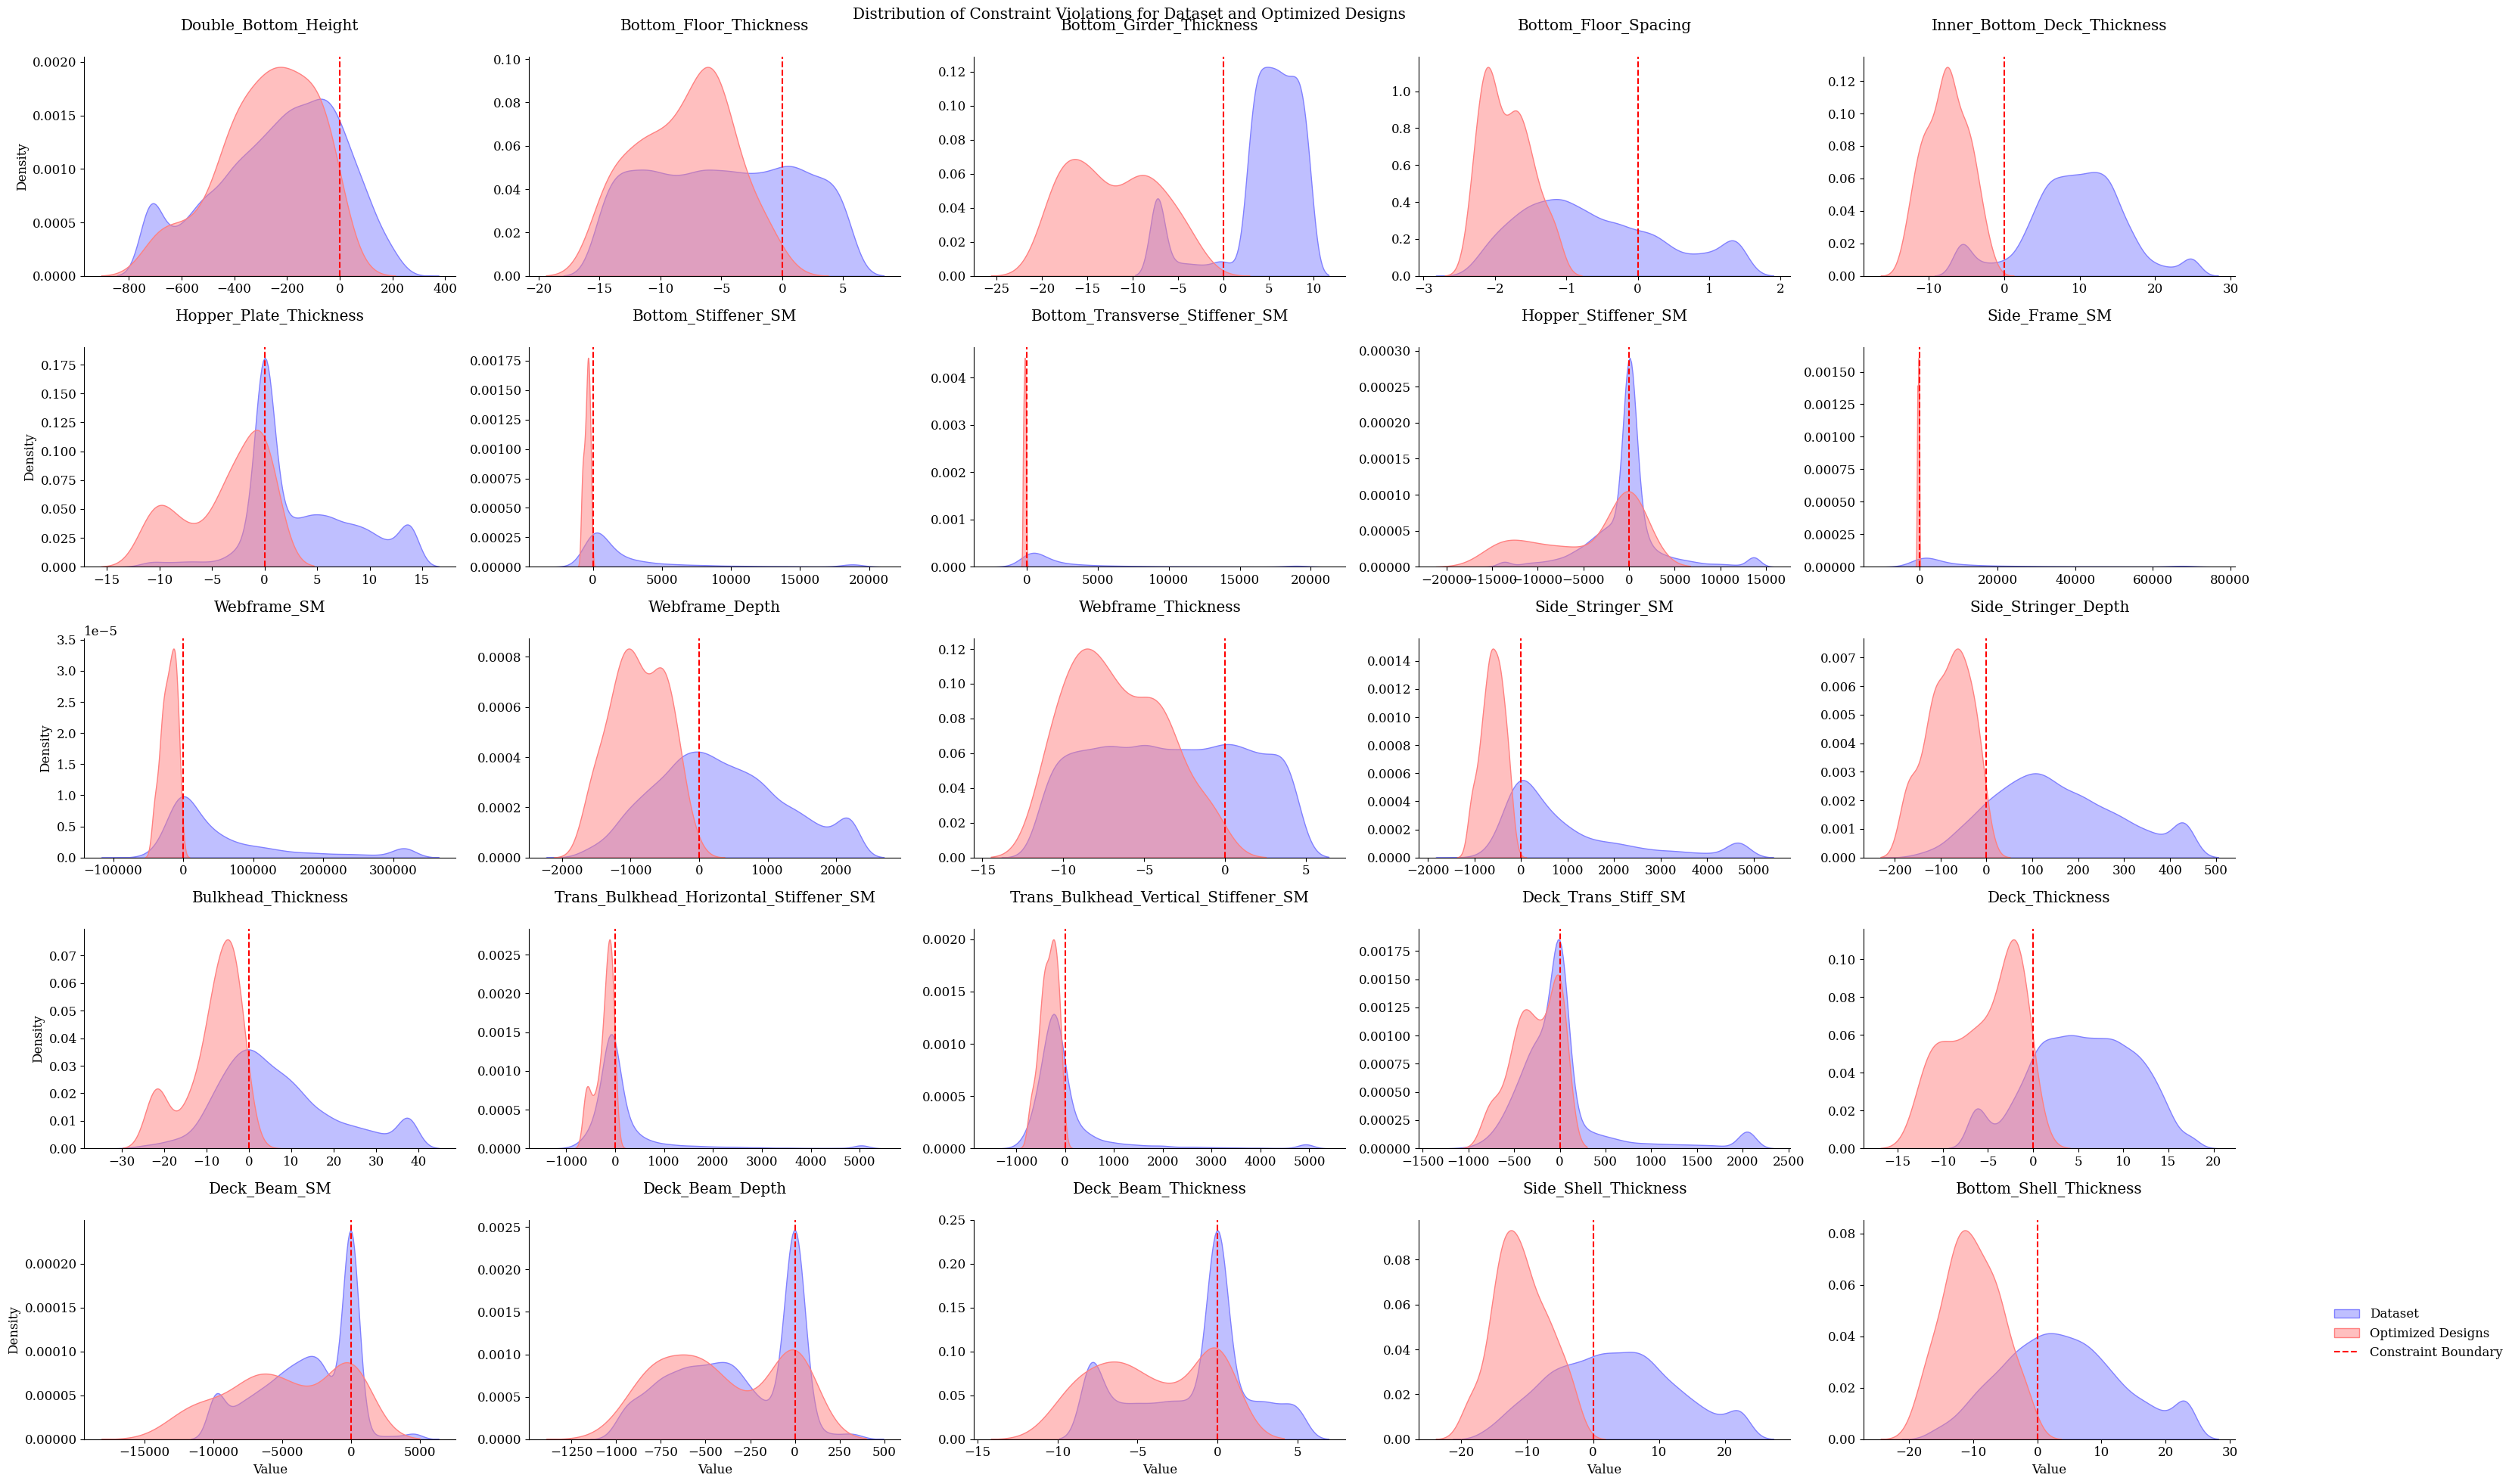

In [29]:
# Now let's plot the differene 

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = '12'

g = sns.FacetGrid(constraint_diff_melted, col='Constraint', sharex=False, sharey=False, height=4, aspect=1.5, col_wrap=5)

for ax, var in zip(g.axes.flatten(),constraint_diff_melted['Constraint'].unique()):
    sns.kdeplot(
        data=constraint_diff_melted[constraint_diff_melted["Constraint"] == var],
        x="Value",
        fill=True,
        ax=ax,
        color=colors[2],
        alpha=0.5
    )

    sns.kdeplot(
        data=constraint_diff_opt_melted[constraint_diff_opt_melted["Constraint"] == var],
        x="Value",
        fill=True,
        ax=ax,
        color=colors[0],
        alpha=0.5
    )

    #add vertical line at x=0 to show the boundary between satisfied and violated constraints
    ax.axvline(x=0, color='r', linestyle='--', label='Constraint Boundary')
    

#Get percent of samples that satisfy each constraint and put it in the title of each subplot
for ax, var in zip(g.axes.flatten(),constraint_diff_melted['Constraint'].unique()):
    total_samples = len(constraint_diff_melted[constraint_diff_melted["Constraint"] == var])
    satisfied_samples = len(constraint_diff_melted[(constraint_diff_melted["Constraint"] == var) & (constraint_diff_melted["Value"] <= 0)])
    fease_rate = satisfied_samples / total_samples
    #ax.set_title(f'{var}, ' + f'Fease. Rate: {fease_rate:.4}', pad=25)
    ax.set_title(f'{var}', pad=25)

g.set_axis_labels("Value", "Density")
#g.set_titles("{col_name}")
plt.suptitle('Distribution of Constraint Violations for Dataset and Optimized Designs')
plt.tight_layout()
ax.legend(['Dataset', 'Optimized Designs', 'Constraint Boundary'], frameon=False, loc='upper right', bbox_to_anchor=(1.75, 0.65))
plt.show()

Number of feasible designs: 100 out of 100 total optimized designs


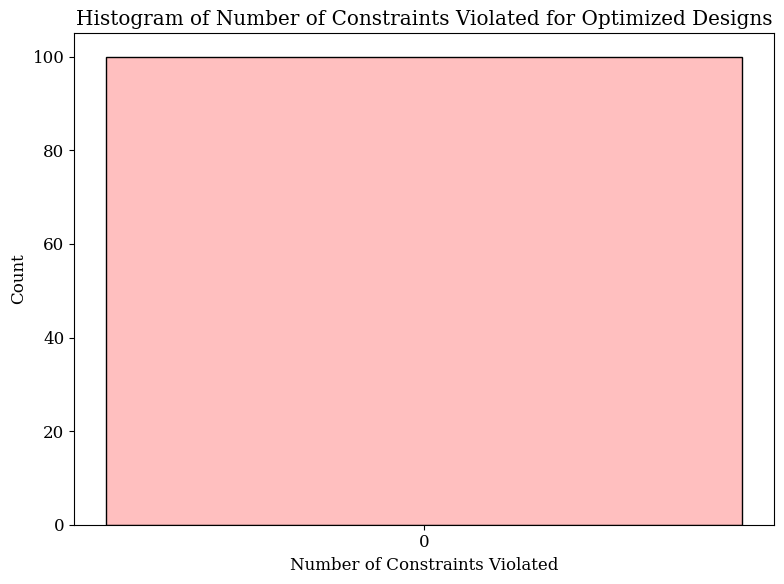

In [30]:
# Let's see which designs satisfy all constraints by looking at the constraint_diff_opt dataframe and counting how many rows have all values <= 0 (meaning they satisfy all constraints)
num_feasible_designs = len(constraint_diff_opt[(constraint_diff_opt <= 0).all(axis=1)])
print(f'Number of feasible designs: {num_feasible_designs} out of {len(constraint_diff_opt)} total optimized designs')

# Lets plot histogram of number of constraints violated for the optimized designs

opt_hist = (constraint_diff_opt > 0).sum(axis=1)

plt.figure(figsize=(8,6))
sns.histplot(opt_hist, bins=np.arange(-0.5, opt_hist.max()+1.5), color=colors[0], alpha=0.5)
plt.xlabel('Number of Constraints Violated')
#Show x ticks for each integer value of number of constraints violated
plt.xticks(np.arange(0, opt_hist.max()+1))
plt.ylabel('Count')
plt.title('Histogram of Number of Constraints Violated for Optimized Designs')
plt.tight_layout()
plt.show()


## Let's extract some stats about the designs ##

In [32]:
# Get the lightest, heaviest, and stiffest structures
path = '/Users/noahbagazinski/Documents/MIT/Research/Ship_Structures/Dataset_Structures_V2_1'
error_idx = np.loadtxt(f"{path}/random_test_design_error_idx_All.csv", delimiter=',', dtype=int)
print("Error indices:", error_idx)

X_data = pd.read_csv(path + '/random_test_design_Parameters_All.csv')
#X_data = X_data.drop(index=error_idx)
#print(len(X_data))
# Reset Index after dropping rows
#X_data = X_data.reset_index(drop=True)

X_optimized = pd.read_csv(f"{opt_file_path}/diverse_dataset_repair_100_004_X_Results_Updated.csv")

Y_optimized = pd.read_csv(f"{opt_file_path}/diverse_dataset_repair_100_004_design_Structural_Properties.csv")

Y_data = pd.read_csv(path + '/random_test_design_Structural_Properties.csv')

x_class_idx = []
x_class_idx.append(X_data[X_data['cat container'] == 1].index)
x_class_idx.append(X_data[X_data['cat tanker'] == 1].index)
x_class_idx.append(X_data[X_data['cat bulkcarrier'] == 1].index)

stiffest_idx = Y_data['Max_Bending_Moment [Nm]'].nlargest(25).index.tolist()
lightest_idx = Y_data['Unit_Steel_Weight [tons/m^3]'].nsmallest(25).index.tolist()

print("Stiffest indices:", stiffest_idx)
print("Lightest indices:", lightest_idx)

#max_I22_idx = Y_data['I_22 [m^4]'].nlargest(25).index.tolist()
#print("Max I22 indices:", max_I22_idx)

# Get idx of stiffest and lightest designs that also satisfy all constraints
Y_fease = Y_data.iloc[feas_idx]

#print(Y_fease)

Y_fease_stiff_idx = Y_fease['Max_Bending_Moment [Nm]'].nlargest(25).index.tolist()
Y_fease_light_idx = Y_fease['Unit_Steel_Weight [tons/m^3]'].nsmallest(25).index.tolist()

print("Feasible Stiffest indices:", Y_fease_stiff_idx)
print("Feasible Lightest indices:", Y_fease_light_idx)

# Get feasible optimized designs that are the stiffest and lightest
opt_fease = constraint_diff_opt[(constraint_diff_opt <= 0).all(axis=1)].index


print(opt_fease)



Error indices: [ 562  683 1185 1335 1979 2239 2292 2435 2699 2975 3106 3349 3380 3402
 3526 3545 3937 4075 4077 4129 4203 4505 4705 4780 4922 4974 5375 5488
 5627 5685]
Stiffest indices: [2060, 1193, 2805, 1261, 712, 5673, 510, 2924, 4828, 1073, 790, 4338, 3329, 2595, 1329, 5728, 4647, 2322, 3710, 5062, 926, 669, 311, 4638, 4311]
Lightest indices: [554, 4618, 3718, 2209, 3716, 1890, 3824, 3566, 44, 740, 1861, 2539, 5596, 4815, 3893, 268, 5670, 3329, 3638, 4988, 2989, 4828, 3808, 1154, 3885]
Feasible Stiffest indices: []
Feasible Lightest indices: []
RangeIndex(start=0, stop=100, step=1)


In [33]:
#Number of each class

print(X_data.shape)

print("Number of Container Ships:", (X_data['cat container'] == 1).sum())
print("Number of Tankers:", (X_data['cat tanker'] == 1).sum())
print("Number of Bulkcarriers:", (X_data['cat bulkcarrier'] == 1).sum())



(6050, 120)
Number of Container Ships: 1935
Number of Tankers: 2007
Number of Bulkcarriers: 2082


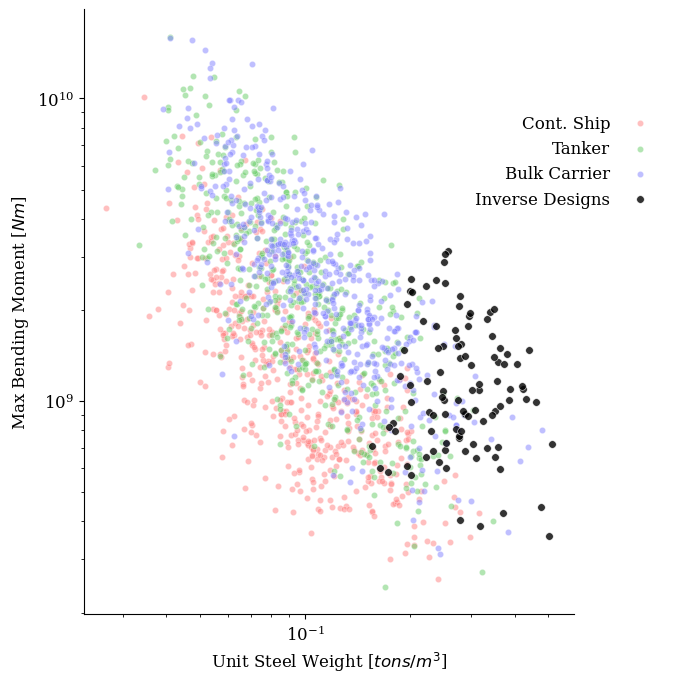

In [34]:
#now make plot of weight and stiffness y values make sure stiff is signed correct
#separate by class, feasibility, and high performing designs
# Remake tsne and add the feasible designs in a different color
feas_color = [1,0,0]
num_plot = 512
Y1 = 'Unit_Steel_Weight [tons/m^3]'
#Y1 = 'Steel_Weight [tons]'
Y2 = 'Max_Bending_Moment [Nm]'

plt.figure(figsize=(7,7))
sns.scatterplot(x=Y_data[Y1][x_class_idx[0][0:num_plot]], y=Y_data[Y2][x_class_idx[0][0:num_plot]], s = 20, color=colors[0], alpha=0.5, label= 'Cont. Ship')
sns.scatterplot(x=Y_data[Y1][x_class_idx[1][0:num_plot]], y=Y_data[Y2][x_class_idx[1][0:num_plot]], s=20, color=colors[1], alpha=0.5, label= 'Tanker')
sns.scatterplot(x=Y_data[Y1][x_class_idx[2][0:num_plot]], y=Y_data[Y2][x_class_idx[2][0:num_plot]], s=20, color=colors[2], alpha=0.5, label= 'Bulk Carrier')

#sns.scatterplot(x=Y_data[Y1][stiffest_idx], y=Y_data[Y2][stiffest_idx], linewidth = 1, marker='X', s=50, color=(0,0,1), alpha=1.0, label= 'Stiffest Designs')
#sns.scatterplot(x=Y_data[Y1][lightest_idx], y=Y_data[Y2][lightest_idx], linewidth = 1, marker='D', s=30, color=(0,0,1), alpha=1.0, label= 'Lightest Designs')

sns.scatterplot(x=Y_optimized[Y1][opt_fease], y=Y_optimized[Y2][opt_fease], color='k', alpha=0.8, label='Inverse Designs', marker='o', s=30)
sns.scatterplot(x=Y_data[Y1][feas_idx], y=Y_data[Y2][feas_idx], linewidth = 1, marker='s', s=30, color=feas_color, alpha=1.0, label= 'Feasible Designs')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)   
# Make x and y on a log scale
plt.xscale('log')
plt.yscale('log') 
#plt.title('Structural Performance of Ship Designs')
plt.xlabel(r'Unit Steel Weight [$tons/m^3$]')
plt.ylabel(r'Max Bending Moment [$Nm$]')
plt.legend(loc='upper right', frameon=False,bbox_to_anchor=(1.2, 0.85), markerfirst=False)
plt.tight_layout()
plt.show()


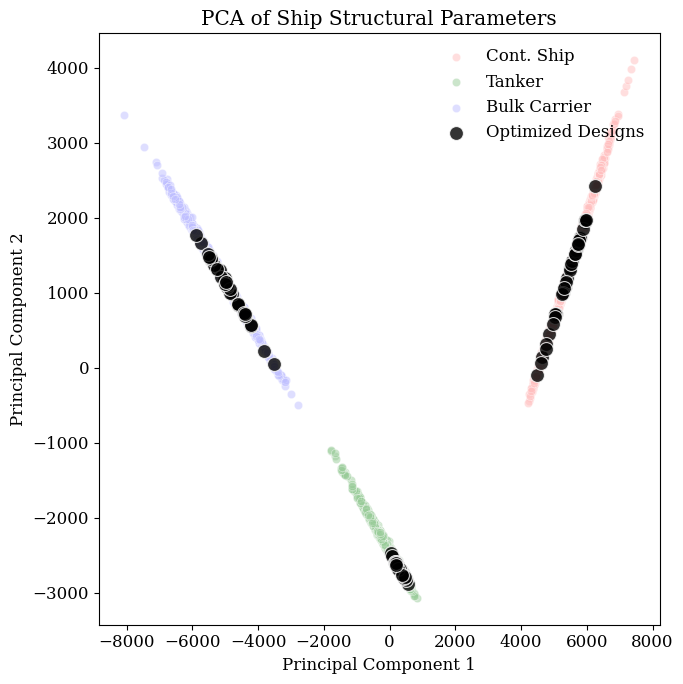

In [35]:
# Now let's make PCA and TSNE plots of the parameters and color by ship class

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


colors = [[1,.75,.75], [.6,0.8,.6], [.75,.75,1]]
# Assign colors based on ship class
ship_class_colors = np.zeros((len(X_data), 3))




#idx_no_error = [idx for idx in range(len(X_data)) if idx not in error_idx]

# FIRST PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_data.values)

X_opt_pca = pca.transform(X_optimized.values)

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = '12'

plt.figure(figsize=(7,7))

sns.scatterplot(x=X_pca[x_class_idx[0],0], y=X_pca[x_class_idx[0],1], color=colors[0], alpha=0.5, label= 'Cont. Ship')
sns.scatterplot(x=X_pca[x_class_idx[1],0], y=X_pca[x_class_idx[1],1], color=colors[1], alpha=0.5, label= 'Tanker')
sns.scatterplot(x=X_pca[x_class_idx[2],0], y=X_pca[x_class_idx[2],1], color=colors[2], alpha=0.5, label= 'Bulk Carrier')
sns.scatterplot(x=X_opt_pca[:,0], y=X_opt_pca[:,1], color='k', alpha=0.8, label='Optimized Designs', marker='o', s=100)

plt.title('PCA of Ship Structural Parameters')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(loc='upper right', frameon=False)
plt.tight_layout()

plt.show()


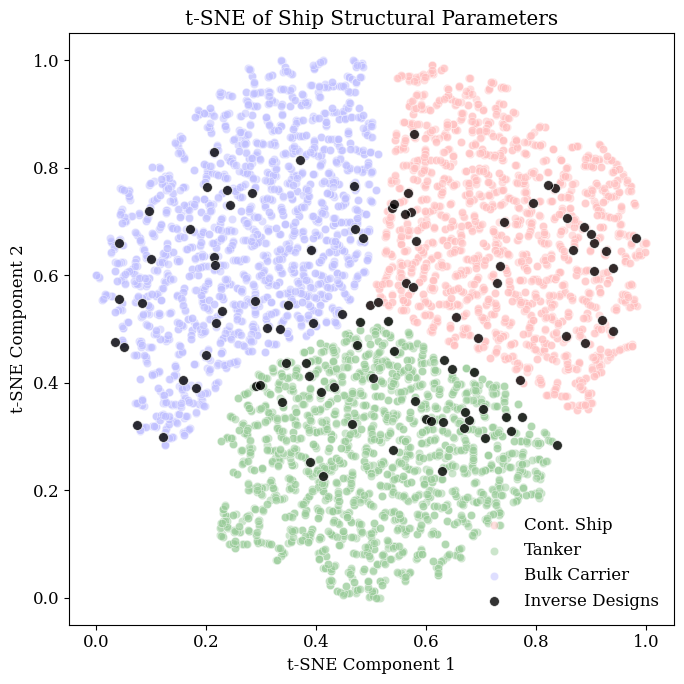

In [36]:
# Now TSNE
#merge x and x_opt for tsne so that they are on the same scale
X_tsne = np.concatenate((X_data.values, X_optimized.values), axis=0)
tsne = TSNE(n_components=2, perplexity=5, max_iter=1000)
X_tsne = tsne.fit_transform(X_tsne)


#Scale TSNE components to be between 0 and 1 for better visualization
X_tsne = (X_tsne - X_tsne.min(axis=0)) / (X_tsne.max(axis=0) - X_tsne.min(axis=0))

plt.figure(figsize=(7,7))
sns.scatterplot(x=X_tsne[x_class_idx[0],0], y=X_tsne[x_class_idx[0],1], color=colors[0], alpha=0.5, label= 'Cont. Ship')
sns.scatterplot(x=X_tsne[x_class_idx[1],0], y=X_tsne[x_class_idx[1],1], color=colors[1], alpha=0.5, label= 'Tanker')
sns.scatterplot(x=X_tsne[x_class_idx[2],0], y=X_tsne[x_class_idx[2],1], color=colors[2], alpha=0.5, label= 'Bulk Carrier')
sns.scatterplot(x=X_tsne[len(X_data):,0], y=X_tsne[len(X_data):,1], color='k', alpha=0.8, label='Inverse Designs', marker='o', s=50)
plt.title('t-SNE of Ship Structural Parameters')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend(loc='lower right', frameon=False)
plt.tight_layout()
plt.show()

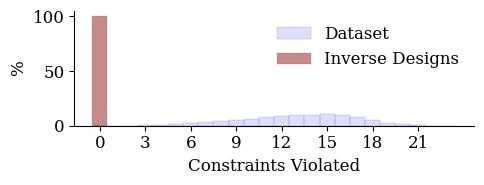

In [37]:
# Make a histogram of the number of constraints violated for the full dataset and for the feasible designs 

#Create a side by side histogram to showcase the optimized designs too values are stored in opt_hist
colors = [[.7,.4,.4], [.6,0.8,.6], [.75,.75,1]]

cons_violations_full = (con_diff > 0).sum(axis=1)
cons_violations_feas = (con_diff.loc[feas_idx] > 0).sum(axis=1)

fig, ax1 = plt.subplots(figsize=(5,2))


sns.histplot(cons_violations_full, bins=np.arange(-0.5, cons_violations_full.max()+1.5), color=colors[2], edgecolor=(0.2,0.2,0.2), linewidth = 0.1, alpha=0.5, label='Dataset',stat='percent')



sns.histplot(opt_hist, bins=np.arange(-0.5, opt_hist.max()+1.5), color=colors[0], edgecolor=(0.2,0.2,0.2), linewidth = 0.1,alpha=0.75, label='Inverse Designs', stat='percent')
ax1.set_ylabel(r'%')

plt.xlabel('Constraints Violated')

#x_ticks for each integer value of number of constraints violated
plt.xticks(np.arange(0, max(cons_violations_full.max(), opt_hist.max())+1,3))
#plt.title('Number of Constraints Violated')

#remove box around axis
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.legend(frameon=False)
plt.tight_layout()
plt.savefig('./Figures/Constraint_Violations_Histogram.png', dpi=450)
plt.show()

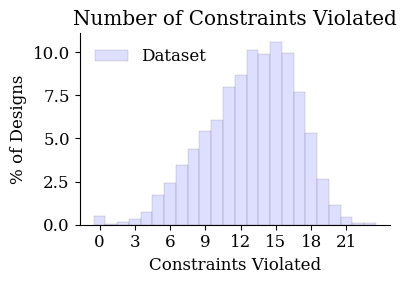

Average number of constraints violated for full dataset: 12.90
Average number of constraints violated for optimized designs: 0.00


In [38]:
# Make a histogram of the number of constraints violated for the full dataset and for the feasible designs 

#Create a side by side histogram to showcase the optimized designs too values are stored in opt_hist
colors = [[.7,.4,.4], [.6,0.8,.6], [.75,.75,1]]

cons_violations_full = (con_diff > 0).sum(axis=1)
cons_violations_feas = (con_diff.loc[feas_idx] > 0).sum(axis=1)

fig, ax1 = plt.subplots(figsize=(4,3))


sns.histplot(cons_violations_full, bins=np.arange(-0.5, cons_violations_full.max()+1.5), color=colors[2], edgecolor=(0.2,0.2,0.2), linewidth = 0.1, alpha=0.5, label='Dataset',stat='percent')



#ns.histplot(opt_hist, bins=np.arange(-0.5, opt_hist.max()+1.5), color=colors[0], edgecolor=(0.2,0.2,0.2), linewidth = 0.1,alpha=0.75, label='Inverse Designs', stat='percent')
ax1.set_ylabel(r'% of Designs')

plt.xlabel('Constraints Violated')

#x_ticks for each integer value of number of constraints violated
plt.xticks(np.arange(0, max(cons_violations_full.max(), opt_hist.max())+1,3))
plt.title('Number of Constraints Violated')

#remove box around axis
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.legend(frameon=False)
plt.tight_layout()
#plt.savefig(f"./Figures/Constraint_Violations_Histogram.png", dpi=300)
plt.show()


#print Average number of constraints violated for the full dataset and for the optimized designs
print(f'Average number of constraints violated for full dataset: {cons_violations_full.mean():.2f}')
print(f'Average number of constraints violated for optimized designs: {opt_hist.mean():.2f}')

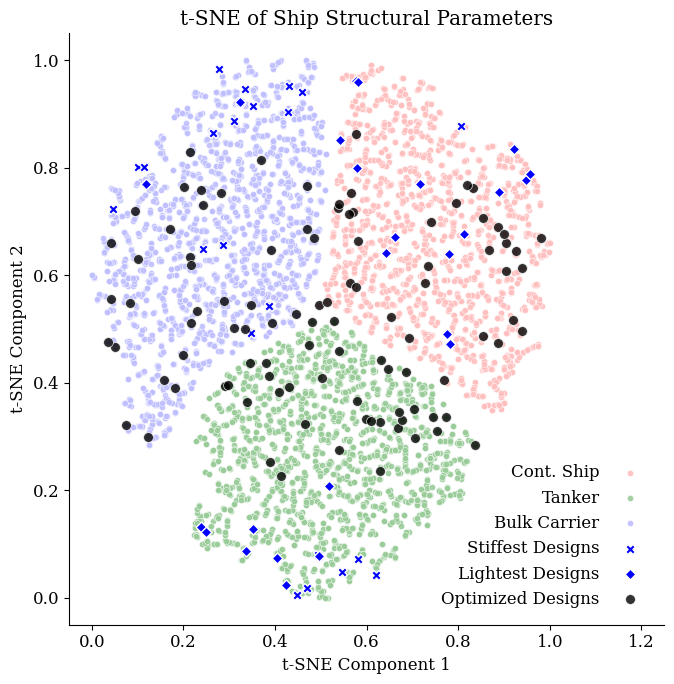

In [39]:
# Remake tsne and add the feasible designs in a different color
feas_color = [1,0,0]
colors = [[1,.75,.75], [.6,0.8,.6], [.75,.75,1]]

plt.figure(figsize=(7,7))
sns.scatterplot(x=X_tsne[x_class_idx[0],0], y=X_tsne[x_class_idx[0],1], s = 20, color=colors[0], alpha=0.9, label= 'Cont. Ship')
sns.scatterplot(x=X_tsne[x_class_idx[1],0], y=X_tsne[x_class_idx[1],1], s=20, color=colors[1], alpha=0.9, label= 'Tanker')
sns.scatterplot(x=X_tsne[x_class_idx[2],0], y=X_tsne[x_class_idx[2],1], s=20, color=colors[2], alpha=0.9, label= 'Bulk Carrier')
sns.scatterplot(x=X_tsne[feas_idx,0], y=X_tsne[feas_idx,1], linewidth = 1, marker='s', s=30, color=feas_color, alpha=1.0, label= 'Feasible Designs')
sns.scatterplot(x=X_tsne[stiffest_idx,0], y=X_tsne[stiffest_idx,1], linewidth = 1, marker='X', s=50, color=(0,0,1), alpha=1.0, label= 'Stiffest Designs')
sns.scatterplot(x=X_tsne[lightest_idx,0], y=X_tsne[lightest_idx,1], linewidth = 1, marker='D', s=30, color=(0,0,1), alpha=1.0, label= 'Lightest Designs')
sns.scatterplot(x=X_tsne[len(X_data):,0], y=X_tsne[len(X_data):,1], color='k', alpha=0.8, label='Optimized Designs', marker='o', s=50)
#remove box around x and y axis
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

#Make x Lim to 1.25
plt.xlim(-0.05,1.25)

plt.title('t-SNE of Ship Structural Parameters')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend(loc='center left', frameon=False,bbox_to_anchor=(0.6, 0.15), markerfirst=False)
plt.tight_layout()
plt.show()

In [40]:
# Try Merging the Constraint Data classes and the performance values with design parameters and retain tsnse 

#X_new = X_data.copy()
X_new = pd.DataFrame()
X_new['cat container'] = X_data['cat container']
X_new['cat tanker'] = X_data['cat tanker']
X_new['cat bulkcarrier'] = X_data['cat bulkcarrier']
#X_new['Unit_Steel_Weight [tons/m^3]'] = Y_data['Unit_Steel_Weight [tons/m^3]']
#X_new['Max_Bending_Moment [Nm]'] = Y_data['Max_Bending_Moment [Nm]']

# add all y
#for col in Y_data.columns:
    #X_new[col] = Y_data[col]


X_new['Constraints'] = (con_diff <= 0).all(axis=1)

# Add all different constraint violations as separate columns
for col in con_diff.columns:
    X_new[f'{col}_Violation'] = con_diff[col]

# Now let's do tsne on this new data 
tsne = TSNE(n_components=2, perplexity=1, max_iter=250)
X_tsne = tsne.fit_transform(X_new.values)





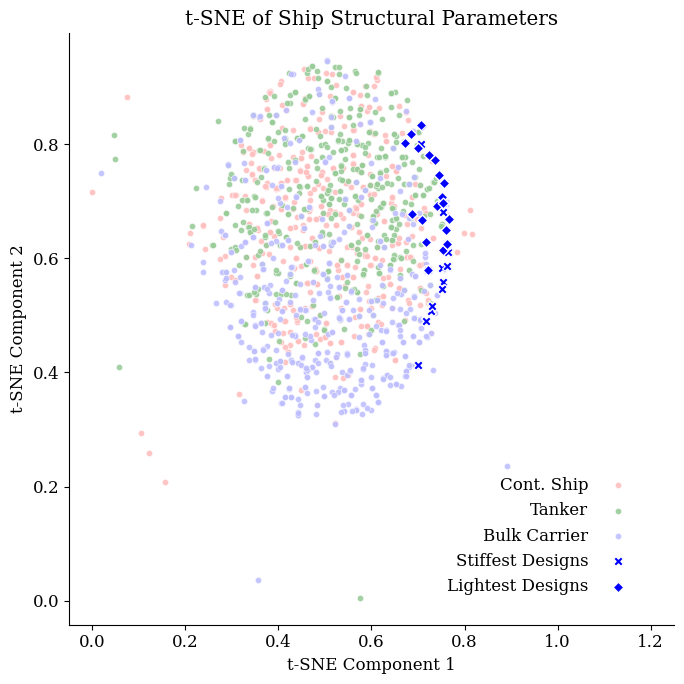

In [41]:
num_plot = 512

plt.figure(figsize=(7,7))
#Scale TSNE components to be between 0 and 1 for better visualization
X_tsne = (X_tsne - X_tsne.min(axis=0)) / (X_tsne.max(axis=0) - X_tsne.min(axis=0))

sns.scatterplot(x=X_tsne[x_class_idx[0][0:num_plot],0], y=X_tsne[x_class_idx[0][0:num_plot],1], s = 20, color=colors[0], alpha=0.9, label= 'Cont. Ship')
sns.scatterplot(x=X_tsne[x_class_idx[1][0:num_plot],0], y=X_tsne[x_class_idx[1][0:num_plot],1], s=20, color=colors[1], alpha=0.9, label= 'Tanker')
sns.scatterplot(x=X_tsne[x_class_idx[2][0:num_plot],0], y=X_tsne[x_class_idx[2][0:num_plot],1], s=20, color=colors[2], alpha=0.9, label= 'Bulk Carrier')
sns.scatterplot(x=X_tsne[feas_idx,0], y=X_tsne[feas_idx,1], linewidth = 1, marker='s', s=30, color=feas_color, alpha=1.0, label= 'Feasible Designs')
sns.scatterplot(x=X_tsne[stiffest_idx,0], y=X_tsne[stiffest_idx,1], linewidth = 1, marker='X', s=50, color=(0,0,1), alpha=1.0, label= 'Stiffest Designs')
sns.scatterplot(x=X_tsne[lightest_idx,0], y=X_tsne[lightest_idx,1], linewidth = 1, marker='D', s=30, color=(0,0,1), alpha=1.0, label= 'Lightest Designs')


#remove box around x and y axis
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

#Make x Lim to 1.25
plt.xlim(-0.05,1.25)

plt.title('t-SNE of Ship Structural Parameters')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend(loc='center left', frameon=False,bbox_to_anchor=(0.6, 0.15), markerfirst=False)
plt.tight_layout()
plt.show()


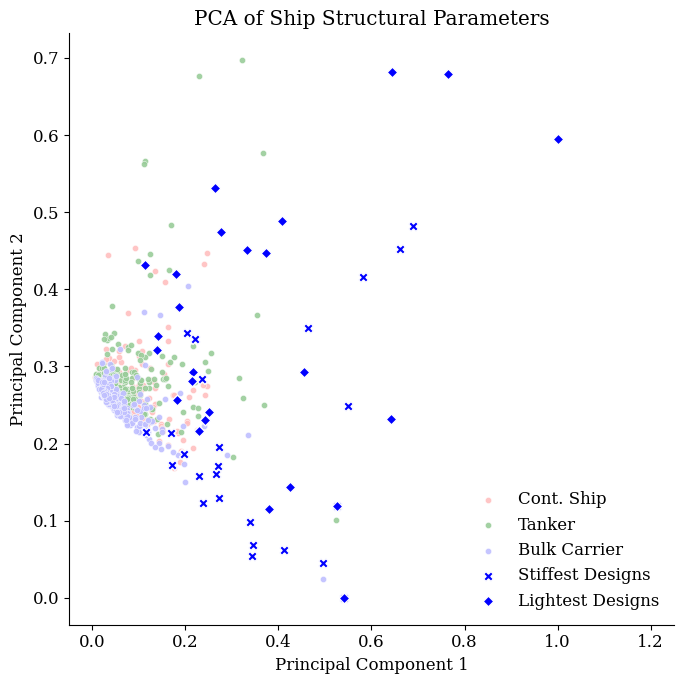

In [42]:
# Let's retry PCA with the new data that includes the performance values and constraint satisfaction as features
num_plot = 512

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_new.values)

X_pca = (X_pca - X_pca.min(axis=0)) / (X_pca.max(axis=0) - X_pca.min(axis=0))

plt.figure(figsize=(7,7))
sns.scatterplot(x=X_pca[x_class_idx[0][0:num_plot],0], y=X_pca[x_class_idx[0][0:num_plot],1], s = 20, color=colors[0], alpha=0.9, label= 'Cont. Ship')
sns.scatterplot(x=X_pca[x_class_idx[1][0:num_plot],0], y=X_pca[x_class_idx[1][0:num_plot],1], s=20, color=colors[1], alpha=0.9, label= 'Tanker')
sns.scatterplot(x=X_pca[x_class_idx[2][0:num_plot],0], y=X_pca[x_class_idx[2][0:num_plot],1], s=20, color=colors[2], alpha=0.9, label= 'Bulk Carrier')
sns.scatterplot(x=X_pca[feas_idx,0], y=X_pca[feas_idx,1], linewidth = 1, marker='s', s=30, color=feas_color, alpha=1.0, label= 'Feasible Designs')
sns.scatterplot(x=X_pca[stiffest_idx,0], y=X_pca[stiffest_idx,1], linewidth = 1, marker='X', s=50, color=(0,0,1), alpha=1.0, label= 'Stiffest Designs')
sns.scatterplot(x=X_pca[lightest_idx,0], y=X_pca[lightest_idx,1], linewidth = 1, marker='D', s=30, color=(0,0,1), alpha=1.0, label= 'Lightest Designs') 


#remove box around x and y axis
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

#Make x Lim to 1.25
plt.xlim(-0.05,1.25)
plt.title('PCA of Ship Structural Parameters')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(loc='lower right', frameon=False)
plt.tight_layout()
plt.show()

In [ ]:
'''

this cell is going to import the design data, the performance data, and the constraint data for the the dataset designs and the generated designs. 

I want to save all the data into a signle dataframe that has the design parameters, the performance values, and the constraint values for each design. I also want to add a column that indicates whether the design is from the dataset or from the generated designs.

The constraints will be imported as the value and the threshold. We need to evaluate the boolean if the value is less than the threshold. 
'''
import pandas as pd
import numpy as np

Designs_data_path = '/Users/noahbagazinski/Documents/MIT/Research/Ship_Structures/Dataset_Structures_V2_1'
Opti_data_path = '/Users/noahbagazinski/Documents/MIT/Research/Ship_Structures/Optimization_Results'



Y_cols = ['Unit_Steel_Weight [tons/m^3]', 'Cross_Sectional_Area [m^2]', 'Max_Bending_Moment [Nm]']


Data_X = pd.read_csv(f"{Designs_data_path}/random_test_design_Parameters_All.csv")
print(Data_X.shape)

Data_Y = pd.read_csv(f"{Designs_data_path}/random_test_design_Structural_Properties.csv")[Y_cols]
cons_vals = pd.read_csv(f"{Designs_data_path}/random_test_design_Constraint_Values.csv")
cons_thresh = pd.read_csv(f"{Designs_data_path}/random_test_design_Constraint_Thresholds.csv")
Data_G = (cons_vals-cons_thresh)>= 0


#Get Error Indices for the dataset and remove them from the dataframes
error_idx = np.loadtxt(f"{Designs_data_path}/random_test_design_error_idx_All.csv", delimiter=',', dtype=int)
Data_X = Data_X.drop(index=error_idx)
Data_Y = Data_Y.drop(index=error_idx)
Data_G = Data_G.drop(index=error_idx)

Opti_X = pd.read_csv(f"{Opti_data_path}/SGD_Opt_1_X_Results.csv")
Opti_Y = pd.read_csv(f"{Opti_data_path}/SGD_Opt_1_design_Structural_Properties.csv")[Y_cols]
Opti_cons_vals = pd.read_csv(f"{Opti_data_path}/SGD_Opt_1_design_Constraint_Values.csv")
Opti_cons_thresh = pd.read_csv(f"{Opti_data_path}/SGD_Opt_1_design_Constraint_Thresholds.csv")
Opti_G = (Opti_cons_vals-Opti_cons_thresh)>= 0

length_data = len(Data_X)+len(Opti_X)

DF = pd.DataFrame(index=range(length_data), columns=list(Data_X.columns)+list(Data_Y.columns)+list(cons_vals.columns)+['Design_Type'])

# Add the dataset designs to the dataframe
DF.iloc[0:len(Data_X), 0:len(Data_X.columns)] = Data_X.values
DF.iloc[0:len(Data_X), len(Data_X.columns):len(Data_X.columns)+len(Data_Y.columns)] = Data_Y.values
DF.iloc[0:len(Data_X), len(Data_X.columns)+len(Data_Y.columns):len(Data_X.columns)+len(Data_Y.columns)+len(Data_G.columns)] = Data_G.values
DF.iloc[0:len(Data_X), -1] = 'Dataset'

# Add the optimized designs to the dataframe
DF.iloc[len(Data_X):, 0:len(Opti_X.columns)] = Opti_X.values
DF.iloc[len(Data_X):, len(Opti_X.columns):len(Opti_X.columns)+len(Opti_Y.columns)] = Opti_Y.values
DF.iloc[len(Data_X):, len(Opti_X.columns)+len(Opti_Y.columns):len(Opti_X.columns)+len(Opti_Y.columns)+len(Opti_G.columns)] = Opti_G.values
DF.iloc[len(Data_X):, -1] = 'Generated'

#Save the dataframe to a csv file
DF.to_csv(f"{Designs_data_path}/Combined_Designs_Data.csv", index=False)


(6050, 120)


No violations:  429


Text(0, 0.5, '% of Designs')

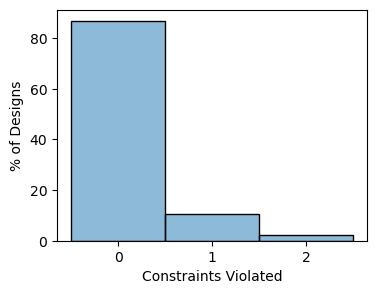

In [ ]:
import pandas as pd
import numpy as np

#Import Claude_Gen_Samples 

Data = pd.read_csv(f"/Users/noahbagazinski/Documents/MIT/Research/Ship_Structures/Claude_Gen_Samples/candidate_feasible_design_Combined_Data.csv")


# Let's make a histogram of the number of constraints violated for the generated designs and the dataset designs (last 25 columns of data)

cons_violations_full = (Data.iloc[:, -25:] == False).sum(axis=1)

print('No violations: ', sum(cons_violations_full==0))

colors = [[.7,.4,.4], [.6,0.8,.6], [.75,.75,1]]

import matplotlib.pyplot as plt
import seaborn as sns

hist = plt.figure(figsize=(4,3))
sns.histplot(cons_violations_full, bins=np.arange(-0.5, cons_violations_full.max()+1.5), alpha=0.5, label='Claude Generated Samples',stat='percent')
plt.xlabel('Constraints Violated')
#x_ticks for each integer value of number of constraints violated
plt.xticks(np.arange(0, cons_violations_full.max()+1, 1))
plt.ylabel(r'% of Designs')
